# Seminar 02. Convexity, Constraints and Optimality Conditions

Checks for every number used in the seminar page, the handout and the cheat sheet. The notebook also writes the data file for the web page, the figures and `values.tex`.

## 1. Setup

Exact values are kept as `Fraction`s where the arithmetic allows.

In [1]:
import inspect
import io
import json
import logging
import math
import re
import zlib
from fractions import Fraction as Fr
from itertools import accumulate, combinations, product
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.optimize import minimize, minimize_scalar

SEED = 42
TOPIC = "02. Convexity, Constraints and Optimality Conditions"
SEMINAR = "02"
NOTEBOOK = f"{TOPIC}.ipynb"


def find_author_root(start):
    """The folder Seminars/Evgeny Baulin, searched from start upwards."""
    for base in (start, *start.parents):
        for cand in (base, base / "Seminars" / "Evgeny Baulin"):
            if (cand / "checks" / NOTEBOOK).is_file():
                return cand
    raise FileNotFoundError(f"Seminars/Evgeny Baulin/checks/{NOTEBOOK} not found above {start}")


AUTHOR = find_author_root(Path.cwd())
NB_PATH = AUTHOR / "checks" / NOTEBOOK
WEB_ROOT = AUTHOR / "web"
WEB = WEB_ROOT / SEMINAR
SHARED = WEB_ROOT / "shared"
VENDOR = SHARED / "vendor"
THEORY = AUTHOR / "theory" / TOPIC
FIG_SVG = WEB / "figures"
FIG_PDF = THEORY / "figures"

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 500)
np.set_printoptions(precision=6, suppress=True)

CHECKS = []
DATA = {}


def _short(value):
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple)):
        value = [str(v) if isinstance(v, Fr) else v for v in value]
    text = str(value)
    return text if len(text) <= 72 else text[:69] + "..."


def check(name, computed, expected, tol=1e-9):
    """Numbers and arrays must agree within tol; strings, booleans and lists of strings must be equal."""
    exact = isinstance(expected, (str, bool, np.bool_)) or (
        isinstance(expected, (list, tuple)) and len(expected) > 0 and all(isinstance(e, str) for e in expected))
    if exact:
        if isinstance(expected, (list, tuple)):
            passed = list(computed) == list(expected)
        else:
            passed = bool(computed == expected)
    else:
        try:
            c = np.asarray(computed, dtype=float)
            e = np.asarray(expected, dtype=float)
            passed = c.shape == e.shape and bool(np.all(np.isfinite(c))) and bool(np.all(np.abs(c - e) <= tol))
        except (TypeError, ValueError):
            passed = False
    CHECKS.append({"check": name, "computed": _short(computed), "expected": _short(expected),
                   "tol": None if exact else tol, "passed": bool(passed)})
    return bool(passed)


def section(prefix):
    """Table of the checks whose names start with prefix."""
    rows = [c for c in CHECKS if c["check"].startswith(prefix)]
    return pd.DataFrame(rows, columns=["check", "computed", "expected", "passed"])


def clean(value):
    """JSON-ready copy of a value, floats rounded to 10 decimals."""
    if isinstance(value, dict):
        return {str(k): clean(v) for k, v in value.items()}
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple)):
        return [clean(v) for v in value]
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    if isinstance(value, Fr):
        value = int(value) if value.denominator == 1 else float(value)
    if isinstance(value, (int, np.integer)):
        return int(value)
    if isinstance(value, (float, np.floating)):
        v = round(float(value), 10)
        if not math.isfinite(v):
            raise ValueError("non-finite value in the export")
        return int(v) if v == int(v) and abs(v) < 2**53 else v
    return value


def put(key, value):
    """Store a value for the export under a dotted key such as 'A1.params.aTest'."""
    assert re.fullmatch(r"[A-Za-z][A-Za-z0-9]*(\.[A-Za-z0-9]+)*", key), key
    node = DATA
    parts = key.split(".")
    for part in parts[:-1]:
        node = node.setdefault(part, {})
        assert isinstance(node, dict), key
    node[parts[-1]] = clean(value)


def fr(x):
    """Exact rational from an int, a decimal string or a Fraction."""
    return x if isinstance(x, Fr) else Fr(str(x)) if isinstance(x, (str, float)) else Fr(x)


def tex_num(x, lang="en", digits=4):
    v = float(x)
    s = f"{v:.{digits}f}".rstrip("0").rstrip(".")
    if s in ("-0", ""):
        s = "0"
    return s.replace(".", "{,}") if lang == "ru" else s


def tex_frac(x):
    q = fr(x)
    if q.denominator == 1:
        return str(q.numerator)
    sign = "-" if q < 0 else ""
    return f"{sign}\\frac{{{abs(q.numerator)}}}{{{q.denominator}}}"


def tex_mat(M):
    rows = r" \\ ".join(" & ".join(tex_num(v) for v in row) for row in M)
    return f"\\begin{{pmatrix}} {rows} \\end{{pmatrix}}"


def tex_poly(terms):
    """sum(coef * monomial) in TeX, e.g. [(1, 'x^2'), (4, 'y^2'), (-2, 'x')]."""
    out = ""
    for coef, mono in terms:
        c = fr(coef)
        if c == 0:
            continue
        sign = "-" if c < 0 else ("+" if out else "")
        mag = abs(c)
        body = (tex_frac(mag) if mag != 1 or not mono else "") + mono
        out += (f" {sign} " if out else sign) + body
    return out.strip() or "0"


def scipy_min(fun, x0, constraints=(), bounds=None):
    """SLSQP with tight tolerances; returns the minimizer."""
    res = minimize(fun, np.asarray(x0, dtype=float), method="SLSQP", constraints=list(constraints),
                   bounds=bounds, options={"ftol": 1e-15, "maxiter": 2000})
    return res.x

## 2. Where is the optimum

$\min\ \|x-c\|^2$ over the unit ball with $c=(1.2,\ 1.6)$, and over $\Delta_3=\{x\in\mathbb R^3:\ x\ge 0,\ \mathbf 1^\top x=1\}$ with $c=(0.6,\ 0.5,\ -0.1)$.

The minimizer is the projection of $c$; the closed forms are compared with SLSQP. Shifting $c$ along $\mathbf 1$ leaves the projection onto $\Delta_3$ unchanged.

In [2]:
def proj_ball(x, center, radius):
    """Euclidean projection onto the ball {y : ||y - center|| <= radius}."""
    x = np.asarray(x, dtype=float)
    center = np.asarray(center, dtype=float)
    d = x - center
    dist = np.linalg.norm(d)
    if dist <= radius:
        return x.copy()
    return center + radius * d / dist


def proj_simplex(v):
    """Euclidean projection onto the probability simplex {x >= 0, sum(x) = 1}, sort-based."""
    v = np.asarray(v, dtype=float)
    u = np.sort(v)[::-1]  # decreasing order
    s = np.cumsum(u)  # cumulative sums
    j = np.arange(1, v.size + 1)
    test = u - (s - 1) / j  # test values; the first one always equals 1
    rho = j[test > 0][-1]  # the last positive test value
    theta = (s[rho - 1] - 1) / rho  # the common shift
    return np.maximum(v - theta, 0.0)


def sq_dist(x, c):
    return float(np.sum((np.asarray(x, dtype=float) - np.asarray(c, dtype=float)) ** 2))


hook_r = 1
hook_c_ball = [fr("1.2"), fr("1.6")]
hook_norm = Fr(math.isqrt(int(sum(t * t for t in hook_c_ball) * 100)), 10)
assert hook_norm**2 == sum(t * t for t in hook_c_ball)
# c is outside the ball: x = c r / ||c||, and 2(x - c) + 2 lam x = 0 gives lam
hook_x_ball = [t * hook_r / hook_norm for t in hook_c_ball]
hook_lam_ball = hook_norm / hook_r - 1
hook_dist2_ball = sum((a - b) ** 2 for a, b in zip(hook_x_ball, hook_c_ball))

c_ball = np.array(hook_c_ball, dtype=float)
x_ball = proj_ball(c_ball, [0, 0], hook_r)
x_ball_slsqp = scipy_min(lambda x: sq_dist(x, c_ball), [0, 0],
                         [{"type": "ineq", "fun": lambda x: hook_r**2 - x @ x}])
check("hook: ball, projection formula", x_ball, hook_x_ball)
check("hook: ball, SLSQP", x_ball_slsqp, hook_x_ball, 1e-6)
check("hook: ball, optimum on the boundary", bool(np.linalg.norm(c_ball) > hook_r), True)
grad_f = 2 * (x_ball - c_ball)
grad_g = 2 * x_ball
lam_ls = np.linalg.lstsq(grad_g[:, None], -grad_f, rcond=None)[0][0]
check("hook: ball, multiplier exact vs least squares", lam_ls, hook_lam_ball)
check("hook: ball, squared distance", sq_dist(x_ball, c_ball), hook_dist2_ball)

hook_c_simplex = [fr("0.6"), fr("0.5"), fr("-0.1")]
c_simp = np.array(hook_c_simplex, dtype=float)
x_simp = proj_simplex(c_simp)
x_simp_slsqp = scipy_min(lambda x: sq_dist(x, c_simp), [1 / 3] * 3,
                         [{"type": "eq", "fun": lambda x: x.sum() - 1}], bounds=[(0, None)] * 3)
hook_x_simplex = [fr("0.55"), fr("0.45"), Fr(0)]
check("hook: simplex, sort-based projection", x_simp, hook_x_simplex)
check("hook: simplex, SLSQP", x_simp_slsqp, hook_x_simplex, 1e-6)
check("hook: simplex, c lies in the plane sum = 1", float(sum(hook_c_simplex)), 1.0)
check("hook: simplex, shift along 1 keeps the projection", proj_simplex(c_simp + 0.37), x_simp, 1e-12)

put("hook.ball.r", hook_r)
put("hook.ball.c", hook_c_ball)
put("hook.ball.norm", hook_norm)
put("hook.ball.x", hook_x_ball)
put("hook.ball.lam", hook_lam_ball)
put("hook.ball.dist2", hook_dist2_ball)
put("hook.ball.onBoundary", True)
put("hook.simplex.c", hook_c_simplex)
put("hook.simplex.x", hook_x_simplex)
put("hook.simplex.theta", fr("0.05"))
put("hook.simplex.dist2", sum((a - b) ** 2 for a, b in zip(hook_x_simplex, hook_c_simplex)))
put("hook.simplex.zeroIndex", 3)
section("hook")

,check,computed,expected,passed
0,"hook: ball, projection formula","[0.6, 0.8]","['3/5', '4/5']",True
1,"hook: ball, SLSQP","[0.5999999990566208, 0.8000000007075366]","['3/5', '4/5']",True
2,"hook: ball, optimum on the boundary",True,True,True
3,"hook: ball, multiplier exact vs least squares",1.0,1,True
4,"hook: ball, squared distance",1.0,1,True
5,"hook: simplex, sort-based projection","[0.5499999999999999, 0.44999999999999996, 0.0]","['11/20', '9/20', '0']",True
6,"hook: simplex, SLSQP","[0.5500000000012473, 0.4499999999987527, 0.0]","['11/20', '9/20', '0']",True
7,"hook: simplex, c lies in the plane sum = 1",1.0,1.0,True
8,"hook: simplex, shift along 1 keeps the projection","[0.55, 0.45000000000000007, 0.0]","[0.5499999999999999, 0.44999999999999996, 0.0]",True


## 3. Convexity

In [3]:
def classify_eigenvalues(eigs, rel_tol=1e-9):
    """Definiteness from eigenvalues, with a tolerance relative to the largest |eigenvalue|."""
    eigs = np.asarray(eigs, dtype=float)
    scale = np.abs(eigs).max(initial=0.0)
    tol = rel_tol * scale
    if scale == 0.0:
        return "zero"
    if np.all(eigs > tol):
        return "positive definite"
    if np.all(eigs >= -tol):
        return "positive semidefinite"
    if np.all(eigs < -tol):
        return "negative definite"
    if np.all(eigs <= tol):
        return "negative semidefinite"
    return "indefinite"


def check_convexity(
    f, hess, sample, n_points=2000, n_pairs=2000, rel_tol=1e-9, seed=42
):
    """Numerical convexity check: Hessian eigenvalues at random points and Jensen on random pairs.

    A violation proves that f is not convex; passing the test is evidence, not a proof.
    """
    rng = np.random.default_rng(seed)
    hessian_counterexample = None
    for _ in range(n_points):
        x = sample(rng)
        eigs = np.linalg.eigvalsh(hess(x))
        if classify_eigenvalues(eigs, rel_tol) not in (
            "zero",
            "positive definite",
            "positive semidefinite",
        ):
            hessian_counterexample = (x, eigs)
            break
    violations, worst = 0, None
    for _ in range(n_pairs):
        x, y, t = sample(rng), sample(rng), rng.random()
        chord = (1 - t) * f(x) + t * f(y)
        value = f((1 - t) * x + t * y)
        if value - chord > rel_tol * max(abs(chord), abs(value)):
            violations += 1
            if worst is None or value - chord > worst[3]:
                worst = (x, y, t, value - chord)
    return {
        "hessian_psd": hessian_counterexample is None,
        "hessian_counterexample": hessian_counterexample,
        "jensen_violations": violations,
        "worst_pair": worst,
    }


def uniform_box(half_width, dim=2):
    return lambda rng: rng.uniform(-half_width, half_width, size=dim)

### Traps in the Hessian test

$10^{-9}\begin{pmatrix}2&1\\1&2\end{pmatrix}$ is positive definite, and an absolute tolerance of $10^{-8}$ calls it zero. The leading minors of $\operatorname{diag}(0,-1)$ are $0,\ 0$, and the matrix is not positive semidefinite. For $f=c\,xy$ the Hessian entry is $c$ and the entry of $A$ in $x^\top Ax$ is $c/2$.

In [4]:
H_tiny = 1e-9 * np.array([[2.0, 1.0], [1.0, 2.0]])
eig_tiny = np.linalg.eigvalsh(H_tiny)
absolute_verdict = "zero" if np.all(np.abs(eig_tiny) <= 1e-8) else "not zero"
check("A traps: absolute tolerance 1e-8 calls a PD matrix zero", absolute_verdict, "zero")
check("A traps: relative tolerance keeps it positive definite", classify_eigenvalues(eig_tiny),
      "positive definite")

M_trap = np.diag([0.0, -1.0])
check("A traps: leading minors of diag(0,-1)", [M_trap[0, 0], np.linalg.det(M_trap)], [0, 0])
check("A traps: principal minor M22 of diag(0,-1)", M_trap[1, 1], -1)
check("A traps: diag(0,-1) classification", classify_eigenvalues(np.linalg.eigvalsh(M_trap)),
      "negative semidefinite")

c_cross = 5.0
xy = np.array([0.3, -0.7])
A_form = np.array([[0, c_cross / 2], [c_cross / 2, 0]])
check("A traps: x^T A x with A_12 = c/2 reproduces c x y", xy @ A_form @ xy, c_cross * xy[0] * xy[1], 1e-12)
fd_h = 1e-4
f_cross = lambda z: c_cross * z[0] * z[1]
mixed = (f_cross(xy + [fd_h, fd_h]) - f_cross(xy + [fd_h, -fd_h])
         - f_cross(xy + [-fd_h, fd_h]) + f_cross(xy - [fd_h, fd_h])) / (4 * fd_h**2)
check("A traps: the Hessian entry of c x y is c (finite differences)", mixed, c_cross, 1e-6)

put("A.traps.crossCoef", 5)
section("A traps")

,check,computed,expected,passed
0,A traps: absolute tolerance 1e-8 calls a PD matrix zero,zero,zero,True
1,A traps: relative tolerance keeps it positive definite,positive definite,positive definite,True
2,"A traps: leading minors of diag(0,-1)","[np.float64(0.0), np.float64(0.0)]","[0, 0]",True
3,"A traps: principal minor M22 of diag(0,-1)",-1.0,-1,True
4,"A traps: diag(0,-1) classification",negative semidefinite,negative semidefinite,True
5,A traps: x^T A x with A_12 = c/2 reproduces c x y,-1.0499999999999998,-1.0499999999999998,True
6,A traps: the Hessian entry of c x y is c (finite differences),5.000000002919336,5.0,True


### A1. A family of quadratics

$f(x,y)=x^2+a\,xy+4y^2+2x$. For which $a$ is $f$ convex, and for which is it strictly convex? Check Jensen at $a=5$ for $p=(0,0)$ and $q=(2,-1)$.

The principal minors are $2$, $8$ and $16-a^2$.

In [5]:
A1_cyy, A1_bx = 4, 2
A1_aTest, A1_aConvex = 5, 3
A1_p, A1_q = [Fr(0), Fr(0)], [Fr(2), Fr(-1)]


def f_A1(z, a):
    x, y = z
    return x * x + a * x * y + A1_cyy * y * y + A1_bx * x


def H_A1(a):
    return np.array([[2.0, a], [a, 2.0 * A1_cyy]])


# exact: det H = 16 - a^2
det_A1 = lambda a: 2 * (2 * A1_cyy) - fr(a) ** 2
a_edge = math.isqrt(2 * (2 * A1_cyy))
assert a_edge**2 == 2 * (2 * A1_cyy)
interval_convex = [-a_edge, a_edge]

# eigenvalues on a grid of a
grid_a = np.linspace(-6, 6, 4801)
psd = np.array([
    classify_eigenvalues(np.linalg.eigvalsh(H_A1(a))) in ("positive definite", "positive semidefinite")
    for a in grid_a
])
pd_mask = np.array([classify_eigenvalues(np.linalg.eigvalsh(H_A1(a))) == "positive definite" for a in grid_a])
check("A1: convex interval, left endpoint (grid vs exact)", grid_a[psd].min(), interval_convex[0], 3e-3)
check("A1: convex interval, right endpoint (grid vs exact)", grid_a[psd].max(), interval_convex[1], 3e-3)
check("A1: at a = ±4 the Hessian is singular, not definite",
      [classify_eigenvalues(np.linalg.eigvalsh(H_A1(s * a_edge))) for s in (-1, 1)],
      ["positive semidefinite"] * 2)
check("A1: strictly convex strictly inside (grid)",
      bool(np.all(pd_mask == (np.abs(grid_a) < a_edge - 1e-12))), True)
for a in (-5.5, -1.3, 0.0, 2.2, 4.7):
    check(f"A1: det H(a) = 16 - a^2 at a = {a}", np.linalg.det(H_A1(a)),
          float(det_A1(Fr(a).limit_denominator(100))), 1e-9)
check("A1: minors at a = 5", [2, 2 * A1_cyy, det_A1(A1_aTest)], [2, 8, -9])

# a = 4: a zero eigenvalue, and f is linear along the null direction
eig_edge = np.linalg.eigvalsh(H_A1(a_edge))
null_dir = np.array([2.0, -1.0])
check("A1: eigenvalues at a = 4", eig_edge, [0, 10], 1e-12)
check("A1: (2,-1) is a null direction at a = 4", H_A1(a_edge) @ null_dir, [0, 0])
s_line = np.linspace(-2, 2, 9)
check("A1: at a = 4, f(2s, -s) = 4s (linear, not strictly convex)",
      [f_A1(s * null_dir, a_edge) for s in s_line], 4 * s_line, 1e-12)

# Jensen at a = 5, exact
A1_m = [(u + w) / 2 for u, w in zip(A1_p, A1_q)]
fp, fq, fm = (f_A1(z, Fr(A1_aTest)) for z in (A1_p, A1_q, A1_m))
avg = (fp + fq) / 2
d = np.array([float(w - u) for u, w in zip(A1_p, A1_q)])
curv = d @ H_A1(A1_aTest) @ d
check("A1: f(p), f(q), f(m) at a = 5", [fp, fq, fm], [0, 2, Fr(3, 2)])
check("A1: Jensen fails at a = 5: f(m) > average", bool(fm > avg), True)
check("A1: midpoint gap equals t(1-t)/2 d^T H d at t = 1/2", float(avg - fm), 0.5 * 0.25 * curv, 1e-12)

# random pairs
res5 = check_convexity(lambda z: f_A1(z, A1_aTest), lambda z: H_A1(A1_aTest), uniform_box(3), n_points=50)
res3 = check_convexity(lambda z: f_A1(z, A1_aConvex), lambda z: H_A1(A1_aConvex), uniform_box(3), n_points=50)
check("A1: random pairs find Jensen violations at a = 5",
      bool(res5["jensen_violations"] > 0 and not res5["hessian_psd"]), True)
check("A1: random pairs find none at a = 3", bool(res3["jensen_violations"] == 0 and res3["hessian_psd"]), True)
check("A1: convex along d at a = 3 (d^T H d > 0)", bool(d @ H_A1(A1_aConvex) @ d > 0), True)

put("A1.params.cyy", A1_cyy)
put("A1.params.bx", A1_bx)
put("A1.params.aTest", A1_aTest)
put("A1.params.aConvex", A1_aConvex)
put("A1.params.aEdge", a_edge)
put("A1.params.p", A1_p)
put("A1.params.q", A1_q)
put("A1.tex.f", tex_poly([(1, "x^2"), (1, "a\\,xy"), (A1_cyy, "y^2"), (A1_bx, "x")]))
put("A1.tex.H", f"\\begin{{pmatrix}} 2 & a \\\\ a & {2 * A1_cyy} \\end{{pmatrix}}")
put("A1.tex.det", tex_poly([(2 * 2 * A1_cyy, ""), (-1, "a^2")]))
put("A1.tex.fEdge", f"(x + {a_edge // 2}y)^2 + {A1_bx}x")
put("A1.tex.HTest", tex_mat(H_A1(A1_aTest)))
put("A1.steps.minor11", 2)
put("A1.steps.minor22", 2 * A1_cyy)
put("A1.steps.detConst", 2 * 2 * A1_cyy)
put("A1.steps.detTest", det_A1(A1_aTest))
put("A1.steps.eigEdge", eig_edge)
put("A1.steps.nullDir", null_dir)
put("A1.steps.lineSlope", 4)
put("A1.steps.m", A1_m)
put("A1.steps.fp", fp)
put("A1.steps.fq", fq)
put("A1.steps.fm", fm)
put("A1.steps.avg", avg)
put("A1.steps.d", d)
put("A1.steps.curv", curv)
put("A1.steps.gap", avg - fm)
put("A1.tex.fm", tex_frac(fm))
put("A1.answer.interval", {"type": "interval", "value": interval_convex, "tol": 1e-6})
put("A1.answer.det", {"type": "formula", "value": f"{2 * 2 * A1_cyy} - a^2", "vars": ["a"], "tol": 1e-8})
put("A1.answer.fm", {"type": "number", "value": fm, "tol": 1e-6})
section("A1")

,check,computed,expected,passed
0,"A1: convex interval, left endpoint (grid vs exact)",-4.0,-4,True
1,"A1: convex interval, right endpoint (grid vs exact)",4.0,4,True
2,"A1: at a = ±4 the Hessian is singular, not definite","['positive semidefinite', 'positive semidefinite']","['positive semidefinite', 'positive semidefinite']",True
3,A1: strictly convex strictly inside (grid),True,True,True
4,A1: det H(a) = 16 - a^2 at a = -5.5,-14.25,-14.25,True
5,A1: det H(a) = 16 - a^2 at a = -1.3,14.310000000000002,14.31,True
6,A1: det H(a) = 16 - a^2 at a = 0.0,15.999999999999998,16.0,True
7,A1: det H(a) = 16 - a^2 at a = 2.2,11.16,11.16,True
8,A1: det H(a) = 16 - a^2 at a = 4.7,-6.090000000000001,-6.09,True
9,A1: minors at a = 5,"[2, 8, '-9']","[2, 8, -9]",True


### A2. $x^2y^2$ is not convex

$f(x,y)=x^2y^2$, $\ H=\begin{pmatrix}2y^2&4xy\\4xy&2x^2\end{pmatrix}$, $\ \det H=-12x^2y^2$. For $p=(1,0)$ and $q=(0,1)$: $f(p)=f(q)=0$ and $f\big(\tfrac{p+q}{2}\big)=\tfrac{1}{16}$.

In [6]:
def f_A2(z):
    x, y = z
    return x * x * y * y


def H_A2(z):
    x, y = z
    return np.array([[2 * y * y, 4 * x * y], [4 * x * y, 2 * x * x]])


def fd_hessian(f, z, h=1e-4):
    """Central finite-difference Hessian."""
    z = np.asarray(z, dtype=float)
    n = z.size
    H = np.zeros((n, n))
    E = np.eye(n) * h
    for i in range(n):
        for j in range(n):
            H[i, j] = (f(z + E[i] + E[j]) - f(z + E[i] - E[j])
                       - f(z - E[i] + E[j]) + f(z - E[i] - E[j])) / (4 * h * h)
    return H


A2_point = [1, 1]
H_A2_pt = H_A2(A2_point)
check("A2: Hessian at (1,1), analytic vs finite differences", H_A2_pt, fd_hessian(f_A2, A2_point), 1e-6)
check("A2: det H(1,1)", np.linalg.det(H_A2_pt), -12, 1e-12)
check("A2: eigenvalues of H(1,1)", np.linalg.eigvalsh(H_A2_pt), [-2, 6], 1e-12)
rng = np.random.default_rng(SEED)
pts = rng.uniform(-2, 2, size=(200, 2))
check("A2: det H = -12 x^2 y^2 at random points", [np.linalg.det(H_A2(z)) for z in pts],
      [-12 * (z[0] * z[1]) ** 2 for z in pts], 1e-9)

A2_p, A2_q = [Fr(1), Fr(0)], [Fr(0), Fr(1)]
A2_m = [(u + w) / 2 for u, w in zip(A2_p, A2_q)]
A2_fm = f_A2(A2_m)
check("A2: f(p) = f(q) = 0", [f_A2(A2_p), f_A2(A2_q)], [0, 0])
check("A2: f(midpoint) = 1/16", A2_fm, Fr(1, 16))
res_A2 = check_convexity(f_A2, H_A2, uniform_box(2), n_points=200)
check("A2: random pairs find violations and an indefinite Hessian",
      bool(res_A2["jensen_violations"] > 0 and not res_A2["hessian_psd"]), True)

put("A2.params.point", A2_point)
put("A2.params.p", A2_p)
put("A2.params.q", A2_q)
put("A2.tex.f", "x^2y^2")
put("A2.tex.H", r"\begin{pmatrix} 2y^2 & 4xy \\ 4xy & 2x^2 \end{pmatrix}")
put("A2.tex.HPoint", tex_mat(H_A2_pt))
put("A2.tex.detGeneral", "-12x^2y^2")
put("A2.steps.detPoint", -12)
put("A2.steps.eig", [-2, 6])
put("A2.steps.m", A2_m)
put("A2.steps.fm", A2_fm)
put("A2.tex.fm", tex_frac(A2_fm))
put("A2.answer.det", {"type": "number", "value": -12, "tol": 1e-6})
put("A2.answer.fm", {"type": "number", "value": A2_fm, "tol": 1e-6})
put("A2.answer.convex", {"type": "single", "value": "no"})
section("A2")

,check,computed,expected,passed
0,"A2: Hessian at (1,1), analytic vs finite differences","[[2, 4], [4, 2]]","[[1.9999999989472883, 3.9999999978945766], [3.9999999978945766, 1.999...",True
1,"A2: det H(1,1)",-12.0,-12,True
2,"A2: eigenvalues of H(1,1)","[-2.0, 6.0]","[-2, 6]",True
3,A2: det H = -12 x^2 y^2 at random points,"[np.float64(-0.8613345383123677), np.float64(-15.388289635469619), np...","[np.float64(-0.8613345383123678), np.float64(-15.388289635469624), np...",True
4,A2: f(p) = f(q) = 0,"['0', '0']","[0, 0]",True
5,A2: f(midpoint) = 1/16,1/16,1/16,True
6,A2: random pairs find violations and an indefinite Hessian,True,True,True


### A3. Sublevel sets and intersections

$S=\{(x,y):\ x^2y^2\le 1\}$, $\ T=\{x^2+y^2\le 4\}\cap\{y\ge x^2-1\}$. Which sets are convex, and which of the pairs $\big((2,\tfrac12),(\tfrac12,2)\big)$, $\big((1,1),(-1,-1)\big)$, $\big((1,0),(0,1)\big)$ shows that $S$ is not?

Random pairs of points inside each set test both answers.

In [7]:
def sample_in(member, half_width, rng, n):
    out = []
    while len(out) < n:
        z = rng.uniform(-half_width, half_width, size=2)
        if member(z):
            out.append(z)
    return np.array(out)


def random_pair_violations(member, half_width, n_pairs, seed):
    """How many random convex combinations of two points of the set fall outside it."""
    rng = np.random.default_rng(seed)
    P = sample_in(member, half_width, rng, n_pairs)
    Q = sample_in(member, half_width, rng, n_pairs)
    t = rng.random(n_pairs)[:, None]
    Z = (1 - t) * P + t * Q
    return int(sum(not member(z) for z in Z))


in_S = lambda z: (z[0] * z[1]) ** 2 <= 1
in_T = lambda z: z[0] ** 2 + z[1] ** 2 <= 4 and z[1] >= z[0] ** 2 - 1
T_radius2, T_shift = 4, 1

pairs = {
    "p1": ([Fr(2), Fr(1, 2)], [Fr(1, 2), Fr(2)]),
    "p2": ([Fr(1), Fr(1)], [Fr(-1), Fr(-1)]),
    "p3": ([Fr(1), Fr(0)], [Fr(0), Fr(1)]),
}
proves = {}
for key, (p, q) in pairs.items():
    m = [(u + w) / 2 for u, w in zip(p, q)]
    proves[key] = in_S(p) and in_S(q) and not in_S(m)
check("A3: only pair p1 proves that S is not convex", [k for k, v in proves.items() if v], ["p1"])
A3_m = [(u + w) / 2 for u, w in zip(*pairs["p1"])]
A3_val = (A3_m[0] * A3_m[1]) ** 2
check("A3: x^2 y^2 at the midpoint of p1", A3_val, Fr(625, 256))

viol_S = random_pair_violations(in_S, 4, 5000, SEED)
viol_T = random_pair_violations(in_T, 2.1, 20000, SEED)
check("A3: random pairs leave S (not convex)", bool(viol_S > 0), True)
check("A3: random pairs never leave T (consistent with convexity)", viol_T, 0)
# both functions that define T are convex
check("A3: Hessian of x^2 + y^2 is PD", classify_eigenvalues([2, 2]), "positive definite")
check("A3: x^2 - 1 is convex (second derivative 2)", classify_eigenvalues([2]), "positive definite")

put("A3.params.p", pairs["p1"][0])
put("A3.params.q", pairs["p1"][1])
put("A3.params.pairs.p1.p", pairs["p1"][0])
put("A3.params.pairs.p1.q", pairs["p1"][1])
put("A3.params.pairs.p2.p", pairs["p2"][0])
put("A3.params.pairs.p2.q", pairs["p2"][1])
put("A3.params.pairs.p3.p", pairs["p3"][0])
put("A3.params.pairs.p3.q", pairs["p3"][1])
put("A3.params.radius2", T_radius2)
put("A3.params.shift", T_shift)
put("A3.tex.S", r"\{(x,y):\ x^2y^2\le 1\}")
put("A3.tex.T", f"\\{{x^2+y^2\\le {T_radius2}\\}}\\cap\\{{y\\ge x^2-{T_shift}\\}}")
put("A3.tex.pHalf", r"\left(2,\ \tfrac12\right)")
put("A3.tex.qHalf", r"\left(\tfrac12,\ 2\right)")
put("A3.tex.mid", r"\left(\tfrac54,\ \tfrac54\right)")
put("A3.tex.xyMid", tex_frac(A3_m[0] * A3_m[1]))
put("A3.tex.val", tex_frac(A3_val))
put("A3.steps.m", A3_m)
put("A3.steps.val", A3_val)
put("A3.answer.convexSets", {"type": "multiple", "value": ["T"]})
put("A3.answer.pair", {"type": "single", "value": "p1"})
put("A.widgets.sublevel.convexA", 2)
put("A.widgets.sublevel.levelConvex", 4)
put("A.widgets.sublevel.levelNonconvex", 1)
put("A.widgets.sets.diskR", 1.5)
put("A.widgets.sets.annulus", [1, 2])
section("A3")

,check,computed,expected,passed
0,A3: only pair p1 proves that S is not convex,['p1'],['p1'],True
1,A3: x^2 y^2 at the midpoint of p1,625/256,625/256,True
2,A3: random pairs leave S (not convex),True,True,True
3,A3: random pairs never leave T (consistent with convexity),0,0,True
4,A3: Hessian of x^2 + y^2 is PD,positive definite,positive definite,True
5,A3: x^2 - 1 is convex (second derivative 2),positive definite,positive definite,True


### A double-well function

$f(x,y)=x^4-2x^2+y^2$, $\ H=\operatorname{diag}(12x^2-4,\ 2)\succeq 0$ exactly for $|x|\ge 1/\sqrt3$.

In [8]:
f_W3 = lambda z: z[0] ** 4 - 2 * z[0] ** 2 + z[1] ** 2
H_W3 = lambda z: np.array([[12 * z[0] ** 2 - 4, 0.0], [0.0, 2.0]])
x_psd = 1 / math.sqrt(3)
z_W3 = [0.7, -0.4]
check("A widgets: W3 Hessian analytic vs finite differences", H_W3(z_W3), fd_hessian(f_W3, z_W3), 1e-6)
grid_x = np.linspace(-1.5, 1.5, 3001)
mask = np.array([classify_eigenvalues(np.linalg.eigvalsh(H_W3([x, 0]))) != "indefinite" for x in grid_x])
check("A widgets: W3 PSD region boundary |x| = 1/sqrt(3)", np.abs(grid_x[mask]).min(), x_psd, 1.5e-3)
put("A.widgets.w3.xPsd", x_psd)
put("A.widgets.w3.tex", "x^4 - 2x^2 + y^2")
section("A widgets")

,check,computed,expected,passed
0,A widgets: W3 Hessian analytic vs finite differences,"[[1.879999999999999, 0.0], [0.0, 2.0]]","[[1.8800000778362858, 0.0], [0.0, 1.9999999989472883]]",True
1,A widgets: W3 PSD region boundary |x| = 1/sqrt(3),0.5779999999999998,0.5773502691896258,True


## 4. Projections

The sort-based projection onto the simplex is computed in exact arithmetic and compared with a search over supports $S$. The projection is the only point with $x_S=v_S-\theta>0$ and $v_i\le\theta$ for $i\notin S$.

In [9]:
def proj_box(x, lower, upper):
    """Euclidean projection onto the box {lower <= y <= upper}: clip every coordinate."""
    return np.clip(np.asarray(x, dtype=float), lower, upper)


def simplex_table(v):
    """Exact rows of the sort-based simplex projection."""
    v = [fr(t) for t in v]
    order = sorted(range(len(v)), key=lambda i: -v[i])
    u = [v[i] for i in order]
    s = list(accumulate(u))
    tests = [u[j] - (s[j] - 1) / (j + 1) for j in range(len(u))]
    rho = max(j + 1 for j in range(len(u)) if tests[j] > 0)
    theta = (s[rho - 1] - 1) / rho
    x = [max(t - theta, Fr(0)) for t in v]
    return {"u": u, "s": s, "tests": tests, "rho": rho, "theta": theta, "x": x}


def simplex_by_supports(v):
    """Projection onto the simplex by trying every support; exactly one support satisfies KKT."""
    v = [fr(t) for t in v]
    n = len(v)
    found = []
    for k in range(1, n + 1):
        for S in combinations(range(n), k):
            theta = (sum(v[i] for i in S) - 1) / k
            x = [v[i] - theta if i in S else Fr(0) for i in range(n)]
            if all(x[i] > 0 for i in S) and all(v[i] <= theta for i in range(n) if i not in S):
                found.append((x, theta))
    assert len(found) == 1, found
    return found[0]


def vertex_products(v, x):
    """(v - x)^T (e_k - x) for every vertex e_k of the simplex; all must be <= 0."""
    r = [a - b for a, b in zip(v, x)]
    rx = sum(a * b for a, b in zip(r, x))
    return [r[k] - rx for k in range(len(v))]


def simplex_slsqp(v):
    v = np.asarray(v, dtype=float)
    return scipy_min(lambda x: sq_dist(x, v), np.full(v.size, 1 / v.size),
                     [{"type": "eq", "fun": lambda x: x.sum() - 1}], bounds=[(0, None)] * v.size)


def random_obtuse_max(v, x, n=2000, seed=SEED):
    """Largest (v - x)^T (y - x) over random points y of the simplex; must be <= 0."""
    rng = np.random.default_rng(seed)
    Y = rng.dirichlet(np.ones(len(v)), size=n)
    r = np.asarray(v, dtype=float) - np.asarray(x, dtype=float)
    return float(((Y - np.asarray(x, dtype=float)) @ r).max())


def export_simplex(pid, v, table):
    put(f"{pid}.params.v", v)
    put(f"{pid}.steps.u", table["u"])
    put(f"{pid}.steps.s", table["s"])
    put(f"{pid}.steps.tests", table["tests"])
    put(f"{pid}.steps.rho", table["rho"])
    put(f"{pid}.steps.theta", table["theta"])
    put(f"{pid}.steps.x", table["x"])
    put(f"{pid}.steps.sumX", sum(table["x"]))
    put(f"{pid}.steps.r", [a - b for a, b in zip(v, table["x"])])
    put(f"{pid}.steps.rx", sum((a - b) * b for a, b in zip(v, table["x"])))
    put(f"{pid}.steps.vertex", vertex_products(v, table["x"]))
    put(f"{pid}.params.n", len(v))
    put(f"{pid}.answer.x", {"type": "vector", "value": table["x"], "tol": 1e-6})
    put(f"{pid}.answer.theta", {"type": "number", "value": table["theta"], "tol": 1e-6})

### B1. Projection onto $\Delta_4$

Project $v=(0.8,\ 1.2,\ -0.4,\ 0.2)$ onto $\Delta_4=\{x\in\mathbb R^4:\ x\ge 0,\ \mathbf 1^\top x=1\}$.

In [10]:
B1_v = [fr(t) for t in ("0.8", "1.2", "-0.4", "0.2")]
B1 = simplex_table(B1_v)
check("B1: sorted values", B1["u"], [fr(t) for t in ("1.2", "0.8", "0.2", "-0.4")])
check("B1: cumulative sums", B1["s"], [fr(t) for t in ("1.2", "2.0", "2.2", "1.8")])
check("B1: test values", B1["tests"], [fr(t) for t in ("1", "0.3", "-0.2", "-0.6")])
check("B1: rho and theta", [B1["rho"], B1["theta"]], [2, Fr(1, 2)])
x_sup, theta_sup = simplex_by_supports(B1_v)
check("B1: projection, table vs supports", B1["x"], x_sup)
check("B1: theta, table vs supports", B1["theta"], theta_sup)
check("B1: projection, numpy sort-based vs exact", proj_simplex(np.array(B1_v, dtype=float)), B1["x"], 1e-12)
check("B1: projection, SLSQP", simplex_slsqp(B1_v), B1["x"], 1e-6)
check("B1: sum of the result", sum(B1["x"]), 1)
check("B1: obtuse angle at the vertices", vertex_products(B1_v, B1["x"]),
      [Fr(0), Fr(0), fr("-0.9"), fr("-0.3")])
check("B1: obtuse angle at random simplex points", bool(random_obtuse_max(B1_v, B1["x"]) <= 1e-12), True)
export_simplex("B1", B1_v, B1)
section("B1")

,check,computed,expected,passed
0,B1: sorted values,"['6/5', '4/5', '1/5', '-2/5']","['6/5', '4/5', '1/5', '-2/5']",True
1,B1: cumulative sums,"['6/5', '2', '11/5', '9/5']","['6/5', '2', '11/5', '9/5']",True
2,B1: test values,"['1', '3/10', '-1/5', '-3/5']","['1', '3/10', '-1/5', '-3/5']",True
3,B1: rho and theta,"[2, '1/2']","[2, '1/2']",True
4,"B1: projection, table vs supports","['3/10', '7/10', '0', '0']","['3/10', '7/10', '0', '0']",True
5,"B1: theta, table vs supports",1/2,1/2,True
6,"B1: projection, numpy sort-based vs exact","[0.30000000000000004, 0.7, 0.0, 0.0]","['3/10', '7/10', '0', '0']",True
7,"B1: projection, SLSQP","[0.3000000002567243, 0.6999999997432761, 0.0, 2.723515857283587e-16]","['3/10', '7/10', '0', '0']",True
8,B1: sum of the result,1,1,True
9,B1: obtuse angle at the vertices,"['0', '0', '-9/10', '-3/10']","['0', '0', '-9/10', '-3/10']",True


### B2. One point, a ball and a box

Project $x=(0.9,\ 1.2)$ onto the unit ball and onto the box $[-1,1]^2$. Which projection is closer to $x$? The obtuse-angle inequality is checked at $y=(1,0)$ and $y=(-1,-1)$.

In [11]:
B2_x = [fr("0.9"), fr("1.2")]
B2_r, B2_lo, B2_hi = 1, -1, 1
norm2 = sum(t * t for t in B2_x)
B2_norm = Fr(math.isqrt(int(norm2 * 100)), 10)
assert B2_norm**2 == norm2
B2_ball = [t * B2_r / B2_norm for t in B2_x]
B2_box = [min(max(t, B2_lo), B2_hi) for t in B2_x]
B2_dist_ball = B2_norm - B2_r
B2_dist_box = Fr(math.isqrt(int(sum((a - b) ** 2 for a, b in zip(B2_x, B2_box)) * 100)), 10)
assert B2_dist_box**2 == sum((a - b) ** 2 for a, b in zip(B2_x, B2_box))
xb = np.array(B2_x, dtype=float)
check("B2: ball projection, formula vs exact", proj_ball(xb, [0, 0], B2_r), B2_ball, 1e-12)
ball_slsqp = scipy_min(lambda z: sq_dist(z, xb), [0, 0], [{"type": "ineq", "fun": lambda z: B2_r**2 - z @ z}])
check("B2: ball projection, SLSQP", ball_slsqp, B2_ball, 1e-6)
check("B2: box projection, clip vs exact", proj_box(xb, B2_lo, B2_hi), B2_box, 1e-12)
box_slsqp = scipy_min(lambda z: sq_dist(z, xb), [0, 0], bounds=[(B2_lo, B2_hi)] * 2)
check("B2: box projection, SLSQP", box_slsqp, B2_box, 1e-6)
check("B2: distances to the ball and to the box", [B2_dist_ball, B2_dist_box], [fr("0.5"), fr("0.2")])
check("B2: the box contains the ball, so the box is closer", bool(B2_dist_box <= B2_dist_ball), True)
B2_y_ball, B2_y_box = [Fr(1), Fr(0)], [Fr(-1), Fr(-1)]
ob_ball = sum((a - p) * (y - p) for a, p, y in zip(B2_x, B2_ball, B2_y_ball))
ob_box = sum((a - p) * (y - p) for a, p, y in zip(B2_x, B2_box, B2_y_box))
check("B2: obtuse angle, ball, y = (1, 0)", ob_ball, fr("-0.2"))
check("B2: obtuse angle, box, y = (-1, -1)", ob_box, fr("-0.4"))

put("B2.params.x", B2_x)
put("B2.params.r", B2_r)
put("B2.params.lo", B2_lo)
put("B2.params.hi", B2_hi)
put("B2.steps.norm2", norm2)
put("B2.steps.norm", B2_norm)
put("B2.steps.ball", B2_ball)
put("B2.steps.box", B2_box)
put("B2.steps.distBall", B2_dist_ball)
put("B2.steps.distBox", B2_dist_box)
put("B2.steps.yBall", B2_y_ball)
put("B2.steps.yBox", B2_y_box)
put("B2.steps.obtuseBall", ob_ball)
put("B2.steps.obtuseBox", ob_box)
put("B2.answer.ball", {"type": "vector", "value": B2_ball, "tol": 1e-6})
put("B2.answer.box", {"type": "vector", "value": B2_box, "tol": 1e-6})
put("B2.answer.closer", {"type": "single", "value": "box"})
section("B2")

,check,computed,expected,passed
0,"B2: ball projection, formula vs exact","[0.6, 0.7999999999999999]","['3/5', '4/5']",True
1,"B2: ball projection, SLSQP","[0.5999999992464352, 0.8000000005752544]","['3/5', '4/5']",True
2,"B2: box projection, clip vs exact","[0.9, 1.0]","['9/10', 1]",True
3,"B2: box projection, SLSQP","[0.8999999962436643, 1.0]","['9/10', 1]",True
4,B2: distances to the ball and to the box,"['1/2', '1/5']","['1/2', '1/5']",True
5,"B2: the box contains the ball, so the box is closer",True,True,True
6,"B2: obtuse angle, ball, y = (1, 0)",-1/5,-1/5,True
7,"B2: obtuse angle, box, y = (-1, -1)",-2/5,-2/5,True


### B3. A positive coordinate that becomes zero

Project $v=(0.1,\ 1.3,\ 0.5)$ onto $\Delta_3$. The shift of $v$ into the plane $\mathbf 1^\top x=1$ has the same projection.

In [12]:
B3_v = [fr(t) for t in ("0.1", "1.3", "0.5")]
B3 = simplex_table(B3_v)
check("B3: sorted values", B3["u"], [fr(t) for t in ("1.3", "0.5", "0.1")])
check("B3: cumulative sums", B3["s"], [fr(t) for t in ("1.3", "1.8", "1.9")])
check("B3: test values", B3["tests"], [fr(t) for t in ("1", "0.1", "-0.2")])
check("B3: rho and theta", [B3["rho"], B3["theta"]], [2, fr("0.4")])
x_sup, theta_sup = simplex_by_supports(B3_v)
check("B3: projection, table vs supports", B3["x"], x_sup)
check("B3: projection, numpy sort-based vs exact", proj_simplex(np.array(B3_v, dtype=float)), B3["x"], 1e-12)
check("B3: projection, SLSQP", simplex_slsqp(B3_v), B3["x"], 1e-6)
check("B3: result", B3["x"], [Fr(0), fr("0.9"), fr("0.1")])
check("B3: a positive input coordinate becomes zero", bool(B3_v[0] > 0 and B3["x"][0] == 0), True)
check("B3: obtuse angle at the vertices", vertex_products(B3_v, B3["x"]), [fr("-0.3"), Fr(0), Fr(0)])
check("B3: obtuse angle at random simplex points", bool(random_obtuse_max(B3_v, B3["x"]) <= 1e-12), True)
B3_inplane = [t - (sum(B3_v) - 1) / 3 for t in B3_v]
check("B3: the in-plane shift of v has the same projection", simplex_table(B3_inplane)["x"], B3["x"])
export_simplex("B3", B3_v, B3)
put("B3.steps.inPlane", B3_inplane)
put("B3.steps.sumV", sum(B3_v))
put("B.widget.n2", B2_x)
section("B3")

,check,computed,expected,passed
0,B3: sorted values,"['13/10', '1/2', '1/10']","['13/10', '1/2', '1/10']",True
1,B3: cumulative sums,"['13/10', '9/5', '19/10']","['13/10', '9/5', '19/10']",True
2,B3: test values,"['1', '1/10', '-1/5']","['1', '1/10', '-1/5']",True
3,B3: rho and theta,"[2, '2/5']","[2, '2/5']",True
4,"B3: projection, table vs supports","['0', '9/10', '1/10']","['0', '9/10', '1/10']",True
5,"B3: projection, numpy sort-based vs exact","[0.0, 0.9, 0.09999999999999998]","['0', '9/10', '1/10']",True
6,"B3: projection, SLSQP","[0.0, 0.9000000000798277, 0.09999999992017249]","['0', '9/10', '1/10']",True
7,B3: result,"['0', '9/10', '1/10']","['0', '9/10', '1/10']",True
8,B3: a positive input coordinate becomes zero,True,True,True
9,B3: obtuse angle at the vertices,"['-3/10', '0', '0']","['-3/10', '0', '0']",True


## 5. KKT conditions

For $\min f(x)$ subject to $g_i(x)\le 0$ and $h_j(x)=0$ the Lagrangian is $\mathcal L(x,\lambda,\nu)=f(x)+\sum_i\lambda_i g_i(x)+\sum_j\nu_j h_j(x)$ with $\lambda\ge 0$.

For $\min\|x-c\|^2$ subject to $Ax\le b$, the active rows $W$ with right-hand side $w$ give $\mu=2(WW^\top)^{-1}(Wc-w)$ and $x=c-\tfrac12W^\top\mu$. The KKT point is the feasible candidate with $\lambda\ge 0$; SLSQP and least-squares multipliers reproduce it.

In [13]:
def solve_exact(M, rhs):
    """Gaussian elimination over the rationals; None when M is singular."""
    n = len(M)
    T = [[fr(a) for a in row] + [fr(b)] for row, b in zip(M, rhs)]
    for col in range(n):
        piv = next((r for r in range(col, n) if T[r][col] != 0), None)
        if piv is None:
            return None
        T[col], T[piv] = T[piv], T[col]
        for r in range(n):
            if r != col and T[r][col] != 0:
                factor = T[r][col] / T[col][col]
                T[r] = [a - factor * b for a, b in zip(T[r], T[col])]
    return [T[i][n] / T[i][i] for i in range(n)]


def kkt_enumerate(c, A, b, E=(), e=()):
    """Every active set of min ||x - c||^2 s.t. A x <= b, E x = e, in exact arithmetic."""
    c = [fr(t) for t in c]
    A = [[fr(t) for t in row] for row in A]
    b = [fr(t) for t in b]
    E = [[fr(t) for t in row] for row in E]
    e = [fr(t) for t in e]
    n, m, p = len(c), len(A), len(E)
    dot = lambda u, w: sum(s * t for s, t in zip(u, w))
    rows = []
    for k in range(m + 1):
        for S in combinations(range(m), k):
            W = E + [A[i] for i in S]
            w = e + [b[i] for i in S]
            mu = []
            if W:
                sol = solve_exact([[dot(r1, r2) for r2 in W] for r1 in W],
                                  [dot(r, c) - wi for r, wi in zip(W, w)])
                if sol is None:
                    continue
                mu = [2 * t for t in sol]
            lam = [Fr(0)] * m
            for idx, i in enumerate(S):
                lam[i] = mu[p + idx]
            x = [c[t] - Fr(1, 2) * sum(mu[r] * W[r][t] for r in range(len(W))) for t in range(n)]
            g = [dot(A[i], x) - b[i] for i in range(m)]
            primal = all(gi <= 0 for gi in g) and all(dot(E[j], x) == e[j] for j in range(p))
            dual = all(l >= 0 for l in lam)
            rows.append({"active": [i + 1 for i in S], "x": x, "lam": lam, "nu": mu[:p], "g": g,
                         "primal": primal, "dual": dual, "kkt": primal and dual,
                         "f": sum((a - ci) ** 2 for a, ci in zip(x, c))})
    return rows


def kkt_check(grad_f, x, constraints, tol=1e-8):
    """Multipliers of the active constraints from stationarity, and the four KKT residuals.

    constraints: a list of pairs (g, grad_g) for constraints g(x) <= 0.
    """
    x = np.asarray(x, dtype=float)
    g = np.array([gi(x) for gi, _ in constraints])
    active = np.flatnonzero(np.abs(g) <= tol)
    lam = np.zeros(len(constraints))
    if active.size:
        G = np.column_stack([constraints[i][1](x) for i in active])
        lam[active] = np.linalg.lstsq(G, -grad_f(x), rcond=None)[0]
    stationarity = grad_f(x) + sum(
        lam[i] * constraints[i][1](x) for i in range(len(constraints))
    )
    residuals = {
        "stationarity": float(np.linalg.norm(stationarity)),
        "primal feasibility": float(max(g.max(initial=0.0), 0.0)),
        "dual feasibility": float(max(-lam.min(initial=0.0), 0.0)),
        "complementary slackness": float(np.abs(lam * g).max(initial=0.0)),
    }
    return lam, residuals


def linear_constraints(A, b):
    """Pairs (g, grad g) for the rows of A x <= b."""
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    return [(lambda x, a=a, bi=bi: float(a @ x - bi), lambda x, a=a: a.copy()) for a, bi in zip(A, b)]


def solve_C(pid, c, A, b):
    """Checks and export for min ||x - c||^2 s.t. A x <= b; returns all candidates and the KKT point."""
    rows = kkt_enumerate(c, A, b)
    kkt_rows = [r for r in rows if r["kkt"]]
    check(f"{pid}: exactly one KKT candidate", len(kkt_rows), 1)
    best = kkt_rows[0]
    cf = np.array([float(t) for t in c])
    Af = np.array([[float(t) for t in row] for row in A])
    bf = np.array([float(t) for t in b])
    x_sl = scipy_min(lambda z: sq_dist(z, cf), [0, 0],
                     [{"type": "ineq", "fun": lambda z, a=a, bi=bi: bi - a @ z} for a, bi in zip(Af, bf)])
    check(f"{pid}: x*, enumeration vs SLSQP", x_sl, best["x"], 1e-6)
    grad = lambda z: 2 * (np.asarray(z) - cf)
    lam_num, res = kkt_check(grad, np.array(best["x"], dtype=float), linear_constraints(Af, bf))
    check(f"{pid}: multipliers, enumeration vs least squares", lam_num, best["lam"], 1e-9)
    check(f"{pid}: KKT residuals vanish", list(res.values()), [0, 0, 0, 0], 1e-9)
    lam_sl, res_sl = kkt_check(grad, x_sl, linear_constraints(Af, bf), tol=1e-6)
    check(f"{pid}: multipliers at the SLSQP point", lam_sl, best["lam"], 1e-4)
    minus_grad = [-2 * (a - ci) for a, ci in zip(best["x"], c)]
    combo = [sum(best["lam"][i] * fr(A[i][t]) for i in range(len(A))) for t in range(2)]
    check(f"{pid}: -grad f(x*) = sum lambda_i grad g_i", minus_grad, combo)
    put(f"{pid}.params.c", [fr(t) for t in c])
    put(f"{pid}.params.A", [[fr(t) for t in row] for row in A])
    put(f"{pid}.params.b", [fr(t) for t in b])
    put(f"{pid}.steps.minusGrad", minus_grad)
    put(f"{pid}.steps.fStar", best["f"])
    for r in rows:
        key = "S" + ("".join(map(str, r["active"])) or "0")
        put(f"{pid}.cand.{key}.x", r["x"])
        put(f"{pid}.cand.{key}.lam", r["lam"])
        put(f"{pid}.cand.{key}.g", r["g"])
        put(f"{pid}.cand.{key}.primal", r["primal"])
        put(f"{pid}.cand.{key}.dual", r["dual"])
        put(f"{pid}.cand.{key}.kkt", r["kkt"])
    put(f"{pid}.answer.x", {"type": "vector", "value": best["x"], "tol": 1e-6})
    put(f"{pid}.answer.f", {"type": "number", "value": best["f"], "tol": 1e-6})
    return rows, best


def table_C(rows):
    """One row per active set."""
    return pd.DataFrame([
        {
            "active set": "{" + ", ".join(map(str, r["active"])) + "}",
            "x": tuple(str(t) for t in r["x"]),
            "lambda": tuple(str(t) for t in r["lam"]),
            "g(x)": tuple(str(t) for t in r["g"]),
            "primal feasible": r["primal"],
            "lambda >= 0": r["dual"],
            "KKT point": r["kkt"],
        }
        for r in rows
    ])

### C1. One active constraint

$\min\ (x_1-2)^2+(x_2-1)^2$ subject to $x_1+x_2\le 1$. With the constraint $x_1+x_2\le R$ the optimal value $p(R)$ satisfies $p'(1)=-\lambda^*$.

In [14]:
C1_rows, C1 = solve_C("C1", [2, 1], [[1, 1]], [1])
check("C1: x*, lambda*, f*", [*C1["x"], C1["lam"][0], C1["f"]], [1, 0, 2, 2])
check("C1: the inactive candidate (2, 1) is infeasible",
      [C1_rows[0]["x"], C1_rows[0]["primal"]] == [[2, 1], False], True)


def p_of_R(R):
    """Optimal value of C1 with the constraint x1 + x2 <= R, by SLSQP."""
    x = scipy_min(lambda z: sq_dist(z, [2, 1]), [0, 0], [{"type": "ineq", "fun": lambda z: R - z.sum()}])
    return sq_dist(x, [2, 1])


h = 1e-3
dp = (p_of_R(1 + h) - p_of_R(1 - h)) / (2 * h)
check("C1: sensitivity p'(1) = -lambda* (central difference)", dp, -2, 1e-4)
check("C1: closed form p(R) = (3 - R)^2 / 2 at R = 0.5", p_of_R(0.5), (3 - 0.5) ** 2 / 2, 1e-7)
put("C1.answer.lam", {"type": "number", "value": C1["lam"][0], "tol": 1e-6, "sign": "nonneg"})
put("C1.tex.f", "(x_1-2)^2+(x_2-1)^2")
put("C1.tex.g", "x_1+x_2-1")
put("C1.steps.xUnc", [2, 1])
put("C1.steps.gUnc", C1_rows[0]["g"][0])
put("C1.steps.sensitivity", -2)
display(table_C(C1_rows))
section("C1")

,active set,x,lambda,g(x),primal feasible,lambda >= 0,KKT point
0,{},"(2, 1)","(0,)","(2,)",False,True,False
1,{1},"(1, 0)","(2,)","(0,)",True,True,True


,check,computed,expected,passed
0,C1: exactly one KKT candidate,1,1,True
1,"C1: x*, enumeration vs SLSQP","[0.9999999999172164, 8.278474085002506e-11]","['1', '0']",True
2,"C1: multipliers, enumeration vs least squares",[1.9999999999999993],['2'],True
3,C1: KKT residuals vanish,"[9.42055475210265e-16, 0.0, -0.0, 0.0]","[0, 0, 0, 0]",True
4,C1: multipliers at the SLSQP point,[1.9999999999999984],['2'],True
5,C1: -grad f(x*) = sum lambda_i grad g_i,"['2', '2']","['2', '2']",True
6,"C1: x*, lambda*, f*","['1', '0', '2', '2']","[1, 0, 2, 2]",True
7,"C1: the inactive candidate (2, 1) is infeasible",True,True,True
8,C1: sensitivity p'(1) = -lambda* (central difference),-1.9999999999920082,-2,True
9,C1: closed form p(R) = (3 - R)^2 / 2 at R = 0.5,3.1249999999998943,3.125,True


### C2. An inactive constraint

$\min\ (x_1-2)^2+(x_2-1)^2$ subject to $x_1+x_2\le 4$.

In [15]:
C2_rows, C2 = solve_C("C2", [2, 1], [[1, 1]], [4])
check("C2: x*, lambda*, f*", [*C2["x"], C2["lam"][0], C2["f"]], [2, 1, 0, 0])
active_C2 = [r for r in C2_rows if r["active"] == [1]][0]
check("C2: the active candidate", [*active_C2["x"], active_C2["lam"][0]], [Fr(5, 2), Fr(3, 2), -1])
check("C2: it is rejected by the sign of lambda",
      [active_C2["primal"], active_C2["dual"]] == [True, False], True)
put("C2.answer.lam", {"type": "number", "value": 0, "tol": 1e-6, "sign": "nonneg"})
put("C2.tex.f", "(x_1-2)^2+(x_2-1)^2")
put("C2.tex.g", "x_1+x_2-4")
put("C2.steps.gStar", C2["g"][0])
display(table_C(C2_rows))
section("C2")

,active set,x,lambda,g(x),primal feasible,lambda >= 0,KKT point
0,{},"(2, 1)","(0,)","(-1,)",True,True,True
1,{1},"(5/2, 3/2)","(-1,)","(0,)",True,False,False


,check,computed,expected,passed
0,C2: exactly one KKT candidate,1,1,True
1,"C2: x*, enumeration vs SLSQP","[1.9999999971180473, 1.0000000072520852]","['2', '1']",True
2,"C2: multipliers, enumeration vs least squares",[0.0],['0'],True
3,C2: KKT residuals vanish,"[0.0, 0.0, -0.0, 0.0]","[0, 0, 0, 0]",True
4,C2: multipliers at the SLSQP point,[0.0],['0'],True
5,C2: -grad f(x*) = sum lambda_i grad g_i,"['0', '0']","['0', '0']",True
6,"C2: x*, lambda*, f*","['2', '1', '0', '0']","[2, 1, 0, 0]",True
7,C2: the active candidate,"['5/2', '3/2', '-1']","['5/2', '3/2', -1]",True
8,C2: it is rejected by the sign of lambda,True,True,True


### C3. Two constraints

$\min\ (x_1-1)^2+(x_2-3)^2$ subject to $x_1+x_2\le 1$ and $x_1\ge 0$.

In [16]:
C3_rows, C3 = solve_C("C3", [1, 3], [[1, 1], [-1, 0]], [1, 0])
check("C3: x*, lambda*, f*", [*C3["x"], *C3["lam"], C3["f"]], [0, 1, 4, 2, 5])
by_set = {tuple(r["active"]): r for r in C3_rows}
check("C3: {} rejected by feasibility", [by_set[()]["primal"], by_set[()]["x"]] == [False, [1, 3]], True)
S1 = by_set[(1,)]
check("C3: {1} rejected by feasibility (x1 < 0)",
      [S1["x"], S1["lam"][0], S1["primal"]] == [[Fr(-1, 2), Fr(3, 2)], 3, False], True)
S2 = by_set[(2,)]
check("C3: {2} rejected by the sign of lambda2 (and feasibility)",
      [S2["x"], S2["lam"][1], S2["dual"], S2["primal"]] == [[0, 3], -2, False, False], True)
check("C3: {1,2} accepted", by_set[(1, 2)]["kkt"], True)
put("C3.answer.lam", {"type": "vector", "value": C3["lam"], "tol": 1e-6, "sign": "nonneg"})
put("C3.tex.f", "(x_1-1)^2+(x_2-3)^2")
put("C3.tex.g1", "x_1+x_2-1")
put("C3.tex.g2", "-x_1")
display(table_C(C3_rows))
put("C.widget.presets", ["C1", "C2", "C3"])
section("C3")

,active set,x,lambda,g(x),primal feasible,lambda >= 0,KKT point
0,{},"(1, 3)","(0, 0)","(3, -1)",False,True,False
1,{1},"(-1/2, 3/2)","(3, 0)","(0, 1/2)",False,True,False
2,{2},"(0, 3)","(0, -2)","(2, 0)",False,False,False
3,"{1, 2}","(0, 1)","(4, 2)","(0, 0)",True,True,True


,check,computed,expected,passed
0,C3: exactly one KKT candidate,1,1,True
1,"C3: x*, enumeration vs SLSQP","[4.328654620544473e-16, 0.9999999999999994]","['0', '1']",True
2,"C3: multipliers, enumeration vs least squares","[3.999999999999999, 2.0000000000000004]","['4', '2']",True
3,C3: KKT residuals vanish,"[1.6011864169946884e-15, 0.0, -0.0, 0.0]","[0, 0, 0, 0]",True
4,C3: multipliers at the SLSQP point,"[4.000000000000001, 2.0000000000000027]","['4', '2']",True
5,C3: -grad f(x*) = sum lambda_i grad g_i,"['2', '4']","['2', '4']",True
6,"C3: x*, lambda*, f*","['0', '1', '4', '2', '5']","[0, 1, 4, 2, 5]",True
7,C3: {} rejected by feasibility,True,True,True
8,C3: {1} rejected by feasibility (x1 < 0),True,True,True
9,C3: {2} rejected by the sign of lambda2 (and feasibility),True,True,True


## 6. Counterexamples and duality

### D1. Projected gradient on a nonconvex set

$\min\ \|x-c\|^2$ with $c=(0.5,\ 2)$ over the union of the unit disks centred at $(\pm1.5,\ 0)$ and over its convex hull, a capsule. Projected gradient runs from ten random starts on the union and on the capsule. The projections of $c$ onto each disk and onto the capsule are known in closed form.

In [17]:
def projected_gradient(f, grad, x0, project, step=0.1, max_iter=500, tol=1e-10):
    """Projected gradient: x_{k+1} = P(x_k - step * grad(x_k)); stops when the iterate stops moving."""
    x = project(np.asarray(x0, dtype=float))
    path = [x]
    for k in range(1, max_iter + 1):
        x_new = project(x - step * grad(x))
        path.append(x_new)
        if np.linalg.norm(x_new - x) <= tol:
            return x_new, {
                "iterations": k,
                "converged": True,
                "f": f(x_new),
                "path": np.array(path),
            }
        x = x_new
    return x, {
        "iterations": max_iter,
        "converged": False,
        "f": f(x),
        "path": np.array(path),
    }


D1_centers = np.array([[-1.5, 0.0], [1.5, 0.0]])
D1_radius = 1.0
D1_c = np.array([0.5, 2.0])
D1_step = 0.1


def proj_two_disks(x):
    candidates = [proj_ball(x, center, D1_radius) for center in D1_centers]
    dists = [np.linalg.norm(np.asarray(x, dtype=float) - p) for p in candidates]
    return candidates[int(np.argmin(dists))]


def proj_capsule(x):
    a, b = D1_centers
    t = np.clip((np.asarray(x, dtype=float) - a) @ (b - a) / ((b - a) @ (b - a)), 0.0, 1.0)
    return proj_ball(x, a + t * (b - a), D1_radius)


f_D1 = lambda x: sq_dist(x, D1_c)
grad_D1 = lambda x: 2 * (np.asarray(x, dtype=float) - D1_c)
rng = np.random.default_rng(SEED)
D1_starts = np.round(rng.uniform([-3.0, -2.5], [3.0, 2.5], size=(10, 2)), 1)

minimizers = np.array([proj_ball(D1_c, center, D1_radius) for center in D1_centers])
values = np.array([f_D1(p) for p in minimizers])
global_idx = int(np.argmin(values))
check("D1: local minimizers are projections of c onto each disk",
      [np.linalg.norm(m - ctr) for m, ctr in zip(minimizers, D1_centers)], [1, 1], 1e-12)
check("D1: f at the two local minimizers (closed form)", values,
      [9 - 4 * math.sqrt(2), 6 - 2 * math.sqrt(5)], 1e-12)
theta = np.linspace(0, 2 * np.pi, 20001)
boundary = np.concatenate([ctr + D1_radius * np.c_[np.cos(theta), np.sin(theta)] for ctr in D1_centers])
check("D1: global minimum by dense boundary sampling", min(f_D1(p) for p in boundary), values[global_idx], 1e-6)

ends_union, ends_capsule, labels = [], [], []
for s in D1_starts:
    xu, info_u = projected_gradient(f_D1, grad_D1, s, proj_two_disks, step=D1_step)
    xc, info_c = projected_gradient(f_D1, grad_D1, s, proj_capsule, step=D1_step)
    assert info_u["converged"] and info_c["converged"]
    k = int(np.argmin([np.linalg.norm(xu - m) for m in minimizers]))
    check(f"D1: start {tuple(float(t) for t in s)} ends at a local minimizer of the union",
          xu, minimizers[k], 1e-8)
    ends_union.append(xu)
    ends_capsule.append(xc)
    labels.append("global" if k == global_idx else "local")
capsule_star = proj_capsule(D1_c)
check("D1: capsule projection of c", capsule_star, [0.5, 1.0], 1e-12)
check("D1: every run on the capsule ends at one point", np.array(ends_capsule),
      np.tile(capsule_star, (len(D1_starts), 1)), 1e-8)
check("D1: runs on the union end at two different points", sorted(set(labels)), ["global", "local"])

put("D1.params.centers", D1_centers)
put("D1.params.radius", D1_radius)
put("D1.params.c", D1_c)
put("D1.params.step", D1_step)
put("D1.params.tol", 1e-10)
put("D1.params.maxIter", 500)
put("D1.params.starts", D1_starts)
put("D1.result.minimizers", minimizers)
put("D1.result.values", values)
put("D1.result.globalIndex", global_idx)
put("D1.result.endsUnion", np.array(ends_union))
put("D1.result.endsCapsule", np.array(ends_capsule))
put("D1.result.capsule", capsule_star)
put("D1.result.fCapsule", f_D1(capsule_star))
put("D1.result.nLocal", labels.count("local"))
put("D1.result.nGlobal", labels.count("global"))
put("D1.result.nStarts", len(D1_starts))
display(pd.DataFrame({
    "start": [tuple(s.tolist()) for s in D1_starts],
    "end on the union": [tuple(np.round(e, 4).tolist()) for e in ends_union],
    "which": labels,
    "end on the capsule": [tuple(np.round(e, 4).tolist()) for e in ends_capsule],
}))
section("D1")

,start,end on the union,which,end on the capsule
0,"(1.6, -0.3)","(1.0528, 0.8944)",global,"(0.5, 1.0)"
1,"(2.2, 1.0)","(1.0528, 0.8944)",global,"(0.5, 1.0)"
2,"(-2.4, 2.4)","(-0.7929, 0.7071)",local,"(0.5, 1.0)"
3,"(1.6, 1.4)","(1.0528, 0.8944)",global,"(0.5, 1.0)"
4,"(-2.2, -0.2)","(-0.7929, 0.7071)",local,"(0.5, 1.0)"
5,"(-0.8, 2.1)","(-0.7929, 0.7071)",local,"(0.5, 1.0)"
6,"(0.9, 1.6)","(1.0528, 0.8944)",global,"(0.5, 1.0)"
7,"(-0.3, -1.4)","(-0.7929, 0.7071)",local,"(0.5, 1.0)"
8,"(0.3, -2.2)","(1.0528, 0.8944)",global,"(0.5, 1.0)"
9,"(2.0, 0.7)","(1.0528, 0.8944)",global,"(0.5, 1.0)"


,check,computed,expected,passed
0,D1: local minimizers are projections of c onto each disk,"[np.float64(0.9999999999999999), np.float64(0.9999999999999999)]","[1, 1]",True
1,D1: f at the two local minimizers (closed form),"[3.3431457505076203, 1.527864045000421]","[3.3431457505076194, 1.5278640450004204]",True
2,D1: global minimum by dense boundary sampling,1.5278640509233576,1.527864045000421,True
3,"D1: start (1.6, -0.3) ends at a local minimizer of the union","[1.0527864043907988, 0.8944271909452943]","[1.0527864045000421, 0.8944271909999159]",True
4,"D1: start (2.2, 1.0) ends at a local minimizer of the union","[1.0527864046456048, 0.8944271910726972]","[1.0527864045000421, 0.8944271909999159]",True
5,"D1: start (-2.4, 2.4) ends at a local minimizer of the union","[-0.7928932188989931, 0.7071067812720883]","[-0.7928932188134525, 0.7071067811865475]",True
6,"D1: start (1.6, 1.4) ends at a local minimizer of the union","[1.052786404609934, 0.8944271910548619]","[1.0527864045000421, 0.8944271909999159]",True
7,"D1: start (-2.2, -0.2) ends at a local minimizer of the union","[-0.7928932188750801, 0.707106781248175]","[-0.7928932188134525, 0.7071067811865475]",True
8,"D1: start (-0.8, 2.1) ends at a local minimizer of the union","[-0.7928932189122386, 0.7071067812853337]","[-0.7928932188134525, 0.7071067811865475]",True
9,"D1: start (0.9, 1.6) ends at a local minimizer of the union","[1.0527864046262896, 0.8944271910630397]","[1.0527864045000421, 0.8944271909999159]",True


### D2. A constraint qualification fails

$\min\ x$ subject to $x^2\le 0$. The only feasible point is $x^*=0$, and $1+2\lambda x^*=1\ne 0$ for every $\lambda$. The dual function $q(\lambda)=\inf_x(x+\lambda x^2)=-1/(4\lambda)$ tends to $p^*=0$ and never reaches it.

In [18]:
D2_lams = [Fr(1, 4), Fr(1, 2), Fr(1), Fr(2), Fr(4)]
q_D2 = lambda lam: -1 / (4 * lam)
for lam in D2_lams:
    res = minimize_scalar(lambda x, lam=float(lam): x + lam * x * x)
    check(f"D2: q({lam}) closed form vs numeric inner minimization", res.fun, float(q_D2(lam)), 1e-9)
    check(f"D2: minimizer x = -1/(2 lambda) at lambda = {lam}", res.x, float(-1 / (2 * lam)), 1e-5)
check("D2: stationarity residual |1 + 2 lambda x*| at x* = 0 is 1 for every lambda",
      [abs(1 + 2 * float(l) * 0.0) for l in D2_lams], [1] * len(D2_lams))
check("D2: Slater fails: min x^2 = 0 is not negative", bool(minimize_scalar(lambda x: x * x).fun >= 0), True)
check("D2: q < 0 = p* for every sampled lambda", bool(all(q_D2(l) < 0 for l in D2_lams + [Fr(10**6)])), True)
check("D2: q(lambda) -> 0 as lambda grows", float(q_D2(Fr(10**6))), 0, 1e-6)
put("D2.pStar", 0)
put("D2.xStar", 0)
put("D2.samples.lam", D2_lams)
put("D2.samples.q", [q_D2(l) for l in D2_lams])
put("D2.samples.qTex", [tex_frac(q_D2(l)) for l in D2_lams])
put("D2.tex.q", r"-\frac{1}{4\lambda}")
put("D2.tex.xMin", r"-\frac{1}{2\lambda}")
section("D2")

,check,computed,expected,passed
0,D2: q(1/4) closed form vs numeric inner minimization,-1.0,-1.0,True
1,D2: minimizer x = -1/(2 lambda) at lambda = 1/4,-2.0,-2.0,True
2,D2: q(1/2) closed form vs numeric inner minimization,-0.5,-0.5,True
3,D2: minimizer x = -1/(2 lambda) at lambda = 1/2,-1.0000000000000002,-1.0,True
4,D2: q(1) closed form vs numeric inner minimization,-0.25,-0.25,True
5,D2: minimizer x = -1/(2 lambda) at lambda = 1,-0.5,-0.5,True
6,D2: q(2) closed form vs numeric inner minimization,-0.125,-0.125,True
7,D2: minimizer x = -1/(2 lambda) at lambda = 2,-0.25000000000000006,-0.25,True
8,D2: q(4) closed form vs numeric inner minimization,-0.0625,-0.0625,True
9,D2: minimizer x = -1/(2 lambda) at lambda = 4,-0.12499999999999997,-0.125,True


### D3. Duality gap

For C1, $\mathcal L=(x_1-2)^2+(x_2-1)^2+\lambda(x_1+x_2-1)$ is minimized at $x(\lambda)=(2-\lambda/2,\ 1-\lambda/2)$, and $q(\lambda)=2\lambda-\lambda^2/2$ attains $d^*=p^*=2$ at $\lambda=2$.

$\min\ x_1x_2+x_2x_3+x_1x_3$ subject to $x_i^2=1$. With $M(\nu)=\tfrac12(\mathbf 1\mathbf 1^\top-I)+\operatorname{diag}(\nu)$, $\ q(\nu)=-\mathbf 1^\top\nu$ if $M(\nu)\succeq 0$ and $-\infty$ otherwise. For $x=e_i-e_j$, $\ x^\top M(\nu)x=\nu_i+\nu_j-1\ge 0$; summing over the three pairs gives $\mathbf 1^\top\nu\ge\tfrac32$, so $d^*=-\tfrac32<p^*=-1$.

With a single quadratic constraint and a strictly feasible point the gap is zero even for a concave objective: $\min\ -x^2$ subject to $x^2\le 1$.

In [19]:
q_C1 = lambda lam: 2 * lam - lam * lam / 2
for lam in (0, 1, 2, 3, 4):
    res = minimize(lambda z, lam=lam: sq_dist(z, [2, 1]) + lam * (z.sum() - 1), [0.0, 0.0], method="BFGS",
                   options={"gtol": 1e-10})
    check(f"D3: q({lam}) closed form vs numeric inner minimization", res.fun, q_C1(lam), 1e-8)
    check(f"D3: x(lambda) at lambda = {lam}", res.x, [2 - lam / 2, 1 - lam / 2], 1e-5)
best = minimize_scalar(lambda lam: -q_C1(lam), bounds=(0, 10), method="bounded", options={"xatol": 1e-10})
check("D3: dual maximizer equals the C1 multiplier", best.x, C1["lam"][0], 1e-6)
check("D3: d* = p* for C1 (zero gap)", -best.fun, C1["f"], 1e-9)
check("D3: weak duality q(lambda) <= p* on a grid",
      bool(all(q_C1(l) <= float(C1["f"]) + 1e-12 for l in np.linspace(0, 6, 601))), True)

# the Boolean problem
signs = [np.array(s) for s in product([-1, 1], repeat=3)]
obj_bool = lambda x: x[0] * x[1] + x[1] * x[2] + x[0] * x[2]
vals = [obj_bool(s) for s in signs]
p_bool = min(vals)
check("D3: Boolean p* by enumeration", p_bool, -1)
check("D3: Boolean p* attained at 6 of 8 points", vals.count(p_bool), 6)
check("D3: Boolean objective values", sorted(set(vals)), [-1, 3])
A_bool = np.ones((3, 3)) - np.eye(3)
M_of = lambda nu: 0.5 * A_bool + np.diag(nu)
nu_star = np.full(3, 0.5)
check("D3: M(nu*) is PSD with a zero eigenvalue", np.linalg.eigvalsh(M_of(nu_star)), [0, 0, 1.5], 1e-12)
check("D3: symmetric analysis: M(t 1) PSD iff t >= 1/2",
      [classify_eigenvalues(np.linalg.eigvalsh(M_of(np.full(3, t)))) != "indefinite"
       for t in (0.49, 0.5, 0.51)],
      [False, True, True])
for i, j in ((0, 1), (1, 2), (0, 2)):
    x_pair = np.zeros(3)
    x_pair[i], x_pair[j] = 1, -1
    check(f"D3: certificate x = e{i + 1} - e{j + 1} gives x^T M x = nu{i + 1} + nu{j + 1} - 1",
          x_pair @ (0.5 * A_bool) @ x_pair, -1, 1e-12)
grid = np.arange(0, 1.5001, 0.05)
best_grid = -np.inf
for n1 in grid:
    for n2 in grid:
        for n3 in grid:
            nu = np.array([n1, n2, n3])
            if np.linalg.eigvalsh(M_of(nu))[0] >= -1e-12:
                best_grid = max(best_grid, -nu.sum())
d_bool = Fr(-3, 2)
check("D3: Boolean d* by grid search", best_grid, float(d_bool), 1e-9)
rng = np.random.default_rng(SEED)
feasible_q = [-nu.sum() for nu in rng.uniform(0, 3, size=(4000, 3)) if np.linalg.eigvalsh(M_of(nu))[0] >= 0]
check("D3: weak duality: q(nu) <= d* <= p* at random dual-feasible nu",
      bool(max(feasible_q) <= float(d_bool) + 1e-12 and float(d_bool) <= p_bool), True)
check("D3: Boolean gap", p_bool - d_bool, Fr(1, 2))

# S-lemma example: min -x^2 s.t. x^2 <= 1
p_slemma = min(-x * x for x in np.linspace(-1, 1, 20001))
q_slemma = lambda lam: -lam if lam >= 1 else -np.inf
d_slemma = max(q_slemma(l) for l in np.linspace(0, 5, 5001))
check("D3: S-lemma example has zero gap", [p_slemma, d_slemma], [-1, -1], 1e-9)

put("D3.convex.tex.q", r"2\lambda-\frac{\lambda^2}{2}")
put("D3.convex.tex.xLam", r"\left(2-\frac{\lambda}{2},\ 1-\frac{\lambda}{2}\right)")
put("D3.convex.lamStar", C1["lam"][0])
put("D3.convex.dStar", C1["f"])
put("D3.convex.pStar", C1["f"])
put("D3.convex.samples.lam", [0, 1, 2, 3, 4])
put("D3.convex.samples.q", [q_C1(Fr(l)) for l in (0, 1, 2, 3, 4)])
put("D3.bool.pStar", p_bool)
put("D3.bool.dStar", d_bool)
put("D3.bool.gap", p_bool - d_bool)
put("D3.bool.nuStar", [Fr(1, 2)] * 3)
put("D3.bool.values", sorted(set(vals)))
put("D3.bool.nOptimal", vals.count(p_bool))
put("D3.bool.tex.dStar", tex_frac(d_bool))
put("D3.bool.tex.gap", tex_frac(p_bool - d_bool))
put("D3.bool.tex.nuStar", r"\tfrac12\,\mathbf 1")
put("D3.slemma.pStar", -1)
section("D3")

,check,computed,expected,passed
0,D3: q(0) closed form vs numeric inner minimization,1.059908164970798e-16,0.0,True
1,D3: x(lambda) at lambda = 0,"[1.999999992701489, 0.9999999927389701]","[2.0, 1.0]",True
2,D3: q(1) closed form vs numeric inner minimization,1.5,1.5,True
3,D3: x(lambda) at lambda = 1,"[1.4999999980265744, 0.4999999955779339]","[1.5, 0.5]",True
4,D3: q(2) closed form vs numeric inner minimization,1.9999999999999996,2.0,True
5,D3: x(lambda) at lambda = 2,"[0.9999999898691335, -9.639064278985771e-09]","[1.0, 0.0]",True
6,D3: q(3) closed form vs numeric inner minimization,1.5000000000000009,1.5,True
7,D3: x(lambda) at lambda = 3,"[0.49999997016594777, -0.5000000118955]","[0.5, -0.5]",True
8,D3: q(4) closed form vs numeric inner minimization,-1.7763568394002505e-15,0.0,True
9,D3: x(lambda) at lambda = 4,"[9.253379237181241e-15, -1.00000000944232]","[0.0, -1.0]",True


## 7. Timeline

The 80-minute plan. When the session runs late, the cuts are applied in the listed order.

In [20]:
TIMELINE = [
    ("O", [("bridge", "1:00"), ("hook", "3:00"), ("overview", "2:00")]),
    ("A", [("recap", "2:00"), ("P1", "6:00"), ("P23", "7:00"), ("review", "3:00")]),
    ("B", [("recap", "2:00"), ("P1", "6:00"), ("P23", "7:00"), ("review", "3:00")]),
    ("C", [("recap", "2:00"), ("P1", "6:00"), ("P23", "7:00"), ("review", "3:00")]),
    ("D", [("D1", "3:00"), ("D2", "3:00"), ("D3", "4:00")]),
    ("E", [("summary", "1:30"), ("cheatsheet", "0:30"), ("exit", "1:30"), ("home", "0:30"),
           ("bridge", "1:00")]),
]
BUFFER = "5:00"
CUTS = [("D.D2", "0:00"), ("B.review", "1:00"), ("A.review", "1:00"), ("D.D1", "1:00")]


def to_sec(t):
    m, s = t.split(":")
    return int(m) * 60 + int(s)


def to_mmss(sec):
    return f"{sec // 60}:{sec % 60:02d}"


leaves = [(blk, item, t) for blk, items in TIMELINE for item, t in items]
total = sum(to_sec(t) for _, _, t in leaves) + to_sec(BUFFER)
check("timeline: total is exactly 80:00", to_mmss(total), "80:00")
check("timeline: block totals", [to_mmss(sum(to_sec(t) for _, t in items)) for _, items in TIMELINE],
      ["6:00", "18:00", "18:00", "18:00", "10:00", "5:00"])
check("timeline: P2 and P3 timer is 7:00 in every problem block",
      [dict(items)["P23"] for blk, items in TIMELINE if blk in "ABC"], ["7:00"] * 3)
lookup = {f"{blk}.{item}": t for blk, item, t in leaves}
saved = sum(to_sec(lookup[k]) - to_sec(v) for k, v in CUTS)
check("timeline: the cuts save 9:00, more than the buffer", to_mmss(saved), "9:00")

clock = 0
for blk, items in TIMELINE:
    put(f"timeline.start.{blk}", to_mmss(clock))
    for item, t in items:
        put(f"timeline.{blk}.{item}", t)
        put(f"timeline.sec.{blk}.{item}", to_sec(t))
        clock += to_sec(t)
    put(f"timeline.{blk}.total", to_mmss(sum(to_sec(t) for _, t in items)))
put("timeline.start.buffer", to_mmss(clock))
put("timeline.buffer", BUFFER)
put("timeline.sec.buffer", to_sec(BUFFER))
put("timeline.total", to_mmss(total))
put("timeline.blocks", [blk for blk, _ in TIMELINE])
put("timeline.leaves", [f"{blk}.{item}" for blk, item, _ in leaves] + ["buffer"])
for key, t in CUTS:
    put(f"timeline.cut.{key.replace('.', '')}", t)
put("timeline.cut.order", [k for k, _ in CUTS])
put("timeline.cut.saved", to_mmss(saved))
section("timeline")

,check,computed,expected,passed
0,timeline: total is exactly 80:00,80:00,80:00,True
1,timeline: block totals,"['6:00', '18:00', '18:00', '18:00', '10:00', '5:00']","['6:00', '18:00', '18:00', '18:00', '10:00', '5:00']",True
2,timeline: P2 and P3 timer is 7:00 in every problem block,"['7:00', '7:00', '7:00']","['7:00', '7:00', '7:00']",True
3,"timeline: the cuts save 9:00, more than the buffer",9:00,9:00,True


## 8. Exit ticket

1. Is $f(x)=x^4-2x^2$ convex on $\mathbb R$?
2. Project $(1,\ 1,\ 0)$ onto $\Delta_3$.
3. At the optimum $g_2(x^*)=-0.3$. What is $\lambda_2^*$?

The third question is checked on $\min\ (x_1-2)^2+(x_2-1)^2$ subject to $x_1+x_2\le 1$ and $x_1\le 1.3$.

In [21]:
# E1: f''(0) = -4
f_E1 = lambda x: x**4 - 2 * x**2
d2_E1 = lambda x: 12 * x**2 - 4
check("exit E1: f''(0) exact vs finite differences",
      (f_E1(1e-4) - 2 * f_E1(0.0) + f_E1(-1e-4)) / 1e-8, d2_E1(0), 1e-5)
check("exit E1: Jensen fails for -1 and 1", bool(f_E1(Fr(0)) > (f_E1(Fr(-1)) + f_E1(Fr(1))) / 2), True)
put("exit.E1.tex.f", "x^4-2x^2")
put("exit.E1.d2", d2_E1(0))
put("exit.E1.tex.d2", "12x^2-4")
put("exit.E1.answer.convex", {"type": "single", "value": "no"})

# E2: projection of (1, 1, 0) onto the simplex
E2_v = [Fr(1), Fr(1), Fr(0)]
E2 = simplex_table(E2_v)
check("exit E2: projection, table vs supports", E2["x"], simplex_by_supports(E2_v)[0])
check("exit E2: projection", E2["x"], [Fr(1, 2), Fr(1, 2), 0])
put("exit.E2.v", E2_v)
put("exit.E2.x", E2["x"])
put("exit.E2.theta", E2["theta"])
put("exit.E2.answer.x", {"type": "vector", "value": E2["x"], "tol": 1e-6})

# E3: two constraints, the second inactive at the optimum
E3_rows = kkt_enumerate([2, 1], [[1, 1], [1, 0]], [1, fr("1.3")])
E3 = [r for r in E3_rows if r["kkt"]][0]
check("exit E3: instance has g2(x*) = -0.3 and lambda2 = 0", [E3["g"][1], E3["lam"][1]], [fr("-0.3"), 0])
put("exit.E3.g", fr("-0.3"))
put("exit.E3.answer.lam", {"type": "number", "value": 0, "tol": 1e-9, "sign": "nonneg"})
section("exit")

,check,computed,expected,passed
0,exit E1: f''(0) exact vs finite differences,-3.99999998,-4,True
1,exit E1: Jensen fails for -1 and 1,True,True,True
2,"exit E2: projection, table vs supports","['1/2', '1/2', '0']","['1/2', '1/2', '0']",True
3,exit E2: projection,"['1/2', '1/2', '0']","['1/2', '1/2', 0]",True
4,exit E3: instance has g2(x*) = -0.3 and lambda2 = 0,"['-3/10', '0']","['-3/10', 0]",True


## 9. Home practice

### H1. Quadratic over linear

Is $f(x,y)=x^2/y$ convex on $y>0$? Is it strictly convex? Compute $\det H$ at $(1,\ 2)$.

In [22]:
f_H1 = lambda z: z[0] ** 2 / z[1]


def H_H1(z):
    x, y = z
    return np.array([[2 / y, -2 * x / y**2], [-2 * x / y**2, 2 * x**2 / y**3]])


H1_point = [1, 2]
check("home H1: Hessian at (1,2), analytic vs finite differences", H_H1(H1_point),
      fd_hessian(f_H1, H1_point, 1e-4), 1e-6)
check("home H1: Hessian at (1,2)", H_H1(H1_point), [[1, -0.5], [-0.5, 0.25]], 1e-12)
pts_H1 = np.random.default_rng(SEED).uniform([-2, 0.3], [2, 3], size=(100, 2))
check("home H1: det H = 0 at random points", [np.linalg.det(H_H1(z)) for z in pts_H1], [0] * 100, 1e-9)
res_H1 = check_convexity(f_H1, H_H1, lambda rng: rng.uniform([-2, 0.3], [2, 3]), n_points=500)
check("home H1: no Jensen violations and PSD Hessians on y > 0",
      bool(res_H1["jensen_violations"] == 0 and res_H1["hessian_psd"]), True)
check("home H1: linear along the ray (t, 2t), so not strictly convex",
      [f_H1([t, 2 * t]) for t in (0.5, 1, 1.5, 2)], [0.25, 0.5, 0.75, 1.0], 1e-12)
put("home.H1.tex.f", r"\frac{x^2}{y}")
put("home.H1.point", H1_point)
put("home.H1.tex.H",
    r"\begin{pmatrix} \frac{2}{y} & -\frac{2x}{y^2} \\ -\frac{2x}{y^2} & \frac{2x^2}{y^3} \end{pmatrix}")
put("home.H1.tex.HPoint", tex_mat(H_H1(H1_point)))
put("home.H1.ray", [1, 2])
put("home.H1.answer.det", {"type": "number", "value": 0, "tol": 1e-6})
put("home.H1.answer.props", {"type": "multiple", "value": ["convex"]})
section("home H1")

,check,computed,expected,passed
0,"home H1: Hessian at (1,2), analytic vs finite differences","[[1.0, -0.5], [-0.5, 0.25]]","[[0.9999999994736442, -0.5000000011246009], [-0.5000000011246009, 0.2...",True
1,"home H1: Hessian at (1,2)","[[1.0, -0.5], [-0.5, 0.25]]","[[1, -0.5], [-0.5, 0.25]]",True
2,home H1: det H = 0 at random points,"[np.float64(-6.457503341973113e-17), np.float64(1.8809907229406108e-1...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",True
3,home H1: no Jensen violations and PSD Hessians on y > 0,True,True,True
4,"home H1: linear along the ray (t, 2t), so not strictly convex","[0.25, 0.5, 0.75, 1.0]","[0.25, 0.5, 0.75, 1.0]",True


### H2. A shifted ball

Project $x=(4,\ 5)$ onto $\{z:\ \|z-c\|\le 2\}$ with $c=(1,\ 1)$, and check the obtuse-angle inequality at $y=(1,\ 3)$.

In [23]:
H2_c, H2_r, H2_x, H2_y = [Fr(1), Fr(1)], 2, [Fr(4), Fr(5)], [Fr(1), Fr(3)]
diff = [a - b for a, b in zip(H2_x, H2_c)]
H2_dist = Fr(math.isqrt(int(sum(t * t for t in diff))))
assert H2_dist**2 == sum(t * t for t in diff)
H2_P = [ci + H2_r * t / H2_dist for ci, t in zip(H2_c, diff)]
H2_prod = sum((a - p) * (y - p) for a, p, y in zip(H2_x, H2_P, H2_y))
check("home H2: projection, exact vs formula",
      proj_ball(np.array(H2_x, float), np.array(H2_c, float), H2_r), H2_P, 1e-12)
H2_slsqp = scipy_min(lambda z: sq_dist(z, np.array(H2_x, float)), [1, 1],
                     [{"type": "ineq", "fun": lambda z: H2_r**2 - sq_dist(z, [1, 1])}])
check("home H2: projection, SLSQP", H2_slsqp, H2_P, 1e-6)
check("home H2: y lies in the ball", bool(sum((a - b) ** 2 for a, b in zip(H2_y, H2_c)) <= H2_r**2), True)
check("home H2: obtuse-angle product", H2_prod, fr("-1.2"))
put("home.H2.c", H2_c)
put("home.H2.r", H2_r)
put("home.H2.x", H2_x)
put("home.H2.y", H2_y)
put("home.H2.diff", diff)
put("home.H2.dist", H2_dist)
put("home.H2.P", H2_P)
put("home.H2.prod", H2_prod)
put("home.H2.xP", [a - b for a, b in zip(H2_x, H2_P)])
put("home.H2.yP", [a - b for a, b in zip(H2_y, H2_P)])
put("home.H2.distY", Fr(math.isqrt(int(sum((a - b) ** 2 for a, b in zip(H2_y, H2_c))))))
put("home.H2.answer.P", {"type": "vector", "value": H2_P, "tol": 1e-6})
put("home.H2.answer.prod", {"type": "number", "value": H2_prod, "tol": 1e-6})
section("home H2")

,check,computed,expected,passed
0,"home H2: projection, exact vs formula","[2.2, 2.6]","['11/5', '13/5']",True
1,"home H2: projection, SLSQP","[2.200000003665425, 2.599999997250932]","['11/5', '13/5']",True
2,home H2: y lies in the ball,True,True,True
3,home H2: obtuse-angle product,-6/5,-6/5,True


### H3. An equality and an inequality

$\min\ x_1^2+x_2^2$ subject to $x_1+2x_2=5$ and $x_1\ge 2$. Find $x^*$, $\lambda^*$ and $\nu^*$.

In [24]:
H3_rows = kkt_enumerate([0, 0], [[-1, 0]], [-2], E=[[1, 2]], e=[5])
H3 = [r for r in H3_rows if r["kkt"]][0]
check("home H3: x*, lambda, nu", [*H3["x"], H3["lam"][0], H3["nu"][0]], [2, fr("1.5"), fr("2.5"), fr("-1.5")])
check("home H3: the candidate without the inequality is (1, 2), infeasible",
      [H3_rows[0]["x"], H3_rows[0]["primal"]] == [[1, 2], False], True)
check("home H3: f*", H3["f"], fr("6.25"))
x_sl = scipy_min(lambda z: z @ z, [3, 1], [{"type": "eq", "fun": lambda z: z[0] + 2 * z[1] - 5},
                                          {"type": "ineq", "fun": lambda z: z[0] - 2}])
check("home H3: SLSQP", x_sl, H3["x"], 1e-6)
put("home.H3.xFree", H3_rows[0]["x"])
put("home.H3.nuFree", H3_rows[0]["nu"][0])
put("home.H3.x", H3["x"])
put("home.H3.lam", H3["lam"][0])
put("home.H3.nu", H3["nu"][0])
put("home.H3.f", H3["f"])
put("home.H3.rhs", 5)
put("home.H3.bound", 2)
put("home.H3.answer.x", {"type": "vector", "value": H3["x"], "tol": 1e-6})
put("home.H3.answer.lam", {"type": "number", "value": H3["lam"][0], "tol": 1e-6, "sign": "nonneg"})
put("home.H3.answer.nu", {"type": "number", "value": H3["nu"][0], "tol": 1e-6})
section("home H3")

,check,computed,expected,passed
0,"home H3: x*, lambda, nu","['2', '3/2', '5/2', '-3/2']","[2, '3/2', '5/2', '-3/2']",True
1,"home H3: the candidate without the inequality is (1, 2), infeasible",True,True,True
2,home H3: f*,25/4,25/4,True
3,home H3: SLSQP,"[1.9999999999999996, 1.5000000000000002]","['2', '3/2']",True


### H4. Projected gradient on the simplex

$\min\ \tfrac12(x_1^2+2x_2^2+4x_3^2)-x_1-2x_2$ over $\Delta_3$ by projected gradient with step $1/L=\tfrac14$ from $(\tfrac13,\ \tfrac13,\ \tfrac13)$. $x^*$ follows from the KKT conditions on each support.

In [25]:
H4_q, H4_p = [Fr(1), Fr(2), Fr(4)], [Fr(1), Fr(2), Fr(0)]


def f_H4(x):
    return 0.5 * sum(float(q) * t * t for q, t in zip(H4_q, x)) - sum(float(p) * t for p, t in zip(H4_p, x))


def grad_H4(x):
    return np.array([float(q) * t - float(p) for q, p, t in zip(H4_q, H4_p, x)])


H4_step = 1 / max(H4_q)
x_pg, info_pg = projected_gradient(f_H4, grad_H4, [1 / 3] * 3, proj_simplex,
                                   step=float(H4_step), max_iter=2000, tol=1e-13)
# on a support S: x_i = (p_i - mu) / q_i, and mu makes the coordinates sum to 1
sols = []
for k in range(1, 4):
    for S in combinations(range(3), k):
        mu = (sum(H4_p[i] / H4_q[i] for i in S) - 1) / sum(1 / H4_q[i] for i in S)
        x = [(H4_p[i] - mu) / H4_q[i] if i in S else Fr(0) for i in range(3)]
        if all(x[i] > 0 for i in S) and all(H4_p[i] <= mu for i in range(3) if i not in S):
            sols.append((x, mu))
check("home H4: exactly one KKT support", len(sols), 1)
H4_x, H4_mu = sols[0]
H4_f = Fr(1, 2) * sum(q * t * t for q, t in zip(H4_q, H4_x)) - sum(p * t for p, t in zip(H4_p, H4_x))
check("home H4: exact solution", [*H4_x, H4_f], [Fr(1, 3), Fr(2, 3), 0, Fr(-7, 6)])
check("home H4: projected gradient reaches x*", x_pg, H4_x, 1e-9)
check("home H4: projected gradient converged", info_pg["converged"], True)
H4_slsqp = scipy_min(f_H4, [1 / 3] * 3, [{"type": "eq", "fun": lambda z: z.sum() - 1}], bounds=[(0, None)] * 3)
check("home H4: SLSQP", H4_slsqp, H4_x, 1e-6)
put("home.H4.q", H4_q)
put("home.H4.p", H4_p)
put("home.H4.L", max(H4_q))
put("home.H4.step", H4_step)
put("home.H4.x0", [Fr(1, 3)] * 3)
put("home.H4.x", H4_x)
put("home.H4.f", H4_f)
put("home.H4.mu", H4_mu)
put("home.H4.grad", [q * t - p for q, p, t in zip(H4_q, H4_p, H4_x)])
put("home.H4.iterations", info_pg["iterations"])
put("home.H4.tex.x", r"\left(\tfrac13,\ \tfrac23,\ 0\right)")
put("home.H4.tex.f", r"\tfrac12\left(x_1^2+2x_2^2+4x_3^2\right)-x_1-2x_2")
put("home.H4.tex.fStar", tex_frac(H4_f))
put("home.H4.tex.mu", tex_frac(H4_mu))
put("home.H4.answer.x", {"type": "vector", "value": H4_x, "tol": 1e-4})
put("home.H4.answer.f", {"type": "number", "value": H4_f, "tol": 1e-4})
section("home H4")

,check,computed,expected,passed
0,home H4: exactly one KKT support,1,1,True
1,home H4: exact solution,"['1/3', '2/3', '0', '-7/6']","['1/3', '2/3', 0, '-7/6']",True
2,home H4: projected gradient reaches x*,"[0.33333333333340875, 0.6666666666665911, 0.0]","['1/3', '2/3', '0']",True
3,home H4: projected gradient converged,True,True,True
4,home H4: SLSQP,"[0.3333333374746406, 0.6666666625253594, 0.0]","['1/3', '2/3', '0']",True


## 10. Cheat sheet and handout

### Formulas on random inputs

The cheat-sheet projection formulas and convexity inequalities on random data, against SLSQP and the search over supports.

In [26]:
rng = np.random.default_rng(SEED)
worst = {"ball": 0.0, "box": 0.0, "simplex": 0.0, "simplex enum": 0.0}
obtuse = {"ball": -np.inf, "box": -np.inf, "simplex": -np.inf}
for _ in range(20):
    n = 3
    x = rng.normal(scale=2.0, size=n)
    center, radius = rng.normal(size=n), rng.uniform(0.5, 2.0)
    lo = -rng.uniform(0.2, 1.5, size=n)
    hi = rng.uniform(0.2, 1.5, size=n)
    pb = proj_ball(x, center, radius)
    pb_slsqp = scipy_min(lambda z: sq_dist(z, x), center,
                         [{"type": "ineq", "fun": lambda z: radius**2 - sq_dist(z, center)}])
    worst["ball"] = max(worst["ball"], np.abs(pb - pb_slsqp).max())
    px = proj_box(x, lo, hi)
    px_slsqp = scipy_min(lambda z: sq_dist(z, x), np.zeros(n), bounds=list(zip(lo, hi)))
    worst["box"] = max(worst["box"], np.abs(px - px_slsqp).max())
    ps = proj_simplex(x)
    worst["simplex"] = max(worst["simplex"], np.abs(ps - simplex_slsqp(x)).max())
    for _ in range(50):
        radial = rng.uniform() ** (1 / n)
        direction = rng.normal(size=n)
        y_ball = center + radius * radial * (direction / np.linalg.norm(direction))
        y_box = rng.uniform(lo, hi)
        y_simp = rng.dirichlet(np.ones(n))
        obtuse["ball"] = max(obtuse["ball"], (x - pb) @ (y_ball - pb))
        obtuse["box"] = max(obtuse["box"], (x - px) @ (y_box - px))
        obtuse["simplex"] = max(obtuse["simplex"], (x - ps) @ (y_simp - ps))
for _ in range(300):
    n = int(rng.integers(2, 7))
    v = rng.normal(scale=1.5, size=n)
    exact, _ = simplex_by_supports([Fr(float(t)) for t in v])
    enum_error = np.abs(proj_simplex(v) - np.array(exact, dtype=float)).max()
    worst["simplex enum"] = max(worst["simplex enum"], enum_error)
check("cheat sheet: ball projection formula vs SLSQP (20 random points)", worst["ball"], 0, 1e-6)
check("cheat sheet: box projection by clipping vs SLSQP (20 random points)", worst["box"], 0, 1e-6)
check("cheat sheet: sort-based simplex projection vs SLSQP (20 random points)", worst["simplex"], 0, 1e-6)
check("cheat sheet: sort-based simplex projection vs support enumeration (300 random, n = 2..6)",
      worst["simplex enum"], 0, 1e-12)
for name, value in obtuse.items():
    check(f"cheat sheet: obtuse-angle property, {name}", bool(value <= 1e-9), True)

# first-order and Jensen inequalities for random PSD quadratics
viol_first, viol_jensen = 0, 0
for _ in range(50):
    B = rng.normal(size=(3, 3))
    Q = B @ B.T
    b = rng.normal(size=3)
    fq = lambda z, Q=Q, b=b: 0.5 * z @ Q @ z + b @ z
    gq = lambda z, Q=Q, b=b: Q @ z + b
    assert classify_eigenvalues(np.linalg.eigvalsh(Q)) in ("positive definite", "positive semidefinite")
    for _ in range(40):
        x, y, t = rng.normal(size=3), rng.normal(size=3), rng.random()
        viol_first += fq(y) < fq(x) + gq(x) @ (y - x) - 1e-9
        viol_jensen += fq((1 - t) * x + t * y) > (1 - t) * fq(x) + t * fq(y) + 1e-9
check("cheat sheet: first-order test f(y) >= f(x) + grad f(x)^T (y - x) for PSD quadratics", int(viol_first), 0)
check("cheat sheet: Jensen for PSD quadratics", int(viol_jensen), 0)

# an indefinite Hessian: Jensen fails along an eigenvector with a negative eigenvalue
Qn = np.diag([1.0, -0.5, 2.0])
w, V = np.linalg.eigh(Qn)
dneg = V[:, 0]
# t(1-t)/2 d^T Q d at t = 1/2 for f = 1/2 z^T Q z
gap = 0.5 * (0.5 * (dneg @ Qn @ dneg)) * 0.5
fqn = lambda z: 0.5 * z @ Qn @ z
check("cheat sheet: indefinite Hessian gives a Jensen violation along its eigenvector",
      (fqn(np.zeros(3)) + fqn(dneg)) / 2 - fqn(dneg / 2), gap, 1e-12)
section("cheat sheet")

,check,computed,expected,passed
0,cheat sheet: ball projection formula vs SLSQP (20 random points),3.968796757902737e-08,0,True
1,cheat sheet: box projection by clipping vs SLSQP (20 random points),6.884153819219918e-08,0,True
2,cheat sheet: sort-based simplex projection vs SLSQP (20 random points),1.807585237045828e-08,0,True
3,"cheat sheet: sort-based simplex projection vs support enumeration (300 random, n = 2..6)",2.220446049250313e-16,0,True
4,"cheat sheet: obtuse-angle property, ball",True,True,True
5,"cheat sheet: obtuse-angle property, box",True,True,True
6,"cheat sheet: obtuse-angle property, simplex",True,True,True
7,cheat sheet: first-order test f(y) >= f(x) + grad f(x)^T (y - x) for PSD quadratics,0,0,True
8,cheat sheet: Jensen for PSD quadratics,0,0,True
9,cheat sheet: indefinite Hessian gives a Jensen violation along its eigenvector,-0.0625,-0.0625,True


### Worked examples

Numbers for the handout examples that are not part of a problem above.

In [27]:
# a convex combination of two points of the unit disk
ex_x, ex_y, ex_t = [Fr(1), Fr(0)], [Fr(0), Fr(1)], Fr(1, 2)
ex_z = [(1 - ex_t) * a + ex_t * b for a, b in zip(ex_x, ex_y)]
check("examples: the midpoint of (1,0) and (0,1) lies in the unit disk", [*ex_z, sum(v * v for v in ex_z)],
      [Fr(1, 2), Fr(1, 2), Fr(1, 2)])
put("ex.combo.x", ex_x)
put("ex.combo.y", ex_y)
put("ex.combo.t", ex_t)
put("ex.combo.z", ex_z)
put("ex.combo.norm2", sum(v * v for v in ex_z))
put("ex.combo.tex.t", r"\tfrac12")
put("ex.combo.tex.z", r"\left(\tfrac12,\ \tfrac12\right)")
put("ex.combo.tex.norm2", r"\tfrac12")

# a point of T and a point of the epigraph of x^2 - 1
ex_T = [Fr(1), Fr(1)]
check("examples: (1,1) lies in T", [bool(in_T(ex_T)), ex_T[0] ** 2 + ex_T[1] ** 2, ex_T[0] ** 2 - T_shift],
      [True, 2, 0])
put("ex.T.point", ex_T)
put("ex.T.norm2", ex_T[0] ** 2 + ex_T[1] ** 2)
put("ex.T.parab", ex_T[0] ** 2 - T_shift)
ex_epi = [Fr(1), Fr(1, 2)]
check("examples: (1, 1/2) lies in the epigraph of x^2 - 1", bool(ex_epi[1] >= ex_epi[0] ** 2 - T_shift), True)
put("ex.epi.point", ex_epi)
put("ex.epi.value", ex_epi[0] ** 2 - T_shift)

# the first-order inequality for f(x) = x^2 at x = 1, y = 3
fo_x, fo_y = Fr(1), Fr(3)
fo_tangent = fo_x**2 + 2 * fo_x * (fo_y - fo_x)
check("examples: x^2 lies above its tangent at 1, checked at 3",
      [fo_y**2, fo_tangent, bool(fo_y**2 >= fo_tangent)], [9, 5, True])
put("ex.first.x", fo_x)
put("ex.first.y", fo_y)
put("ex.first.fy", fo_y**2)
put("ex.first.fx", fo_x**2)
put("ex.first.slope", 2 * fo_x)
put("ex.first.tangent", fo_tangent)

# the Hessian test for A1 at a = 3
check("examples: A1 at a = 3 has minors 2, 8, 7", [2, 2 * A1_cyy, det_A1(A1_aConvex)], [2, 8, 7])
check("examples: A1 at a = 3 is positive definite", classify_eigenvalues(np.linalg.eigvalsh(H_A1(A1_aConvex))),
      "positive definite")
put("ex.hess.a", A1_aConvex)
put("ex.hess.det", det_A1(A1_aConvex))
put("ex.hess.tex.H", tex_mat(H_A1(A1_aConvex)))

# local and global minimum of D1
put("ex.local.fLocal", values[1 - global_idx])
put("ex.local.fGlobal", values[global_idx])

# a feasible direction at the C1 optimum
ex_d = [Fr(-1), Fr(0)]
grad_g1 = [Fr(1), Fr(1)]
grad_f1 = [2 * (a - ci) for a, ci in zip(C1["x"], [2, 1])]
check("examples: d = (-1, 0) is feasible at the C1 optimum and not a descent direction",
      [sum(a * b for a, b in zip(grad_g1, ex_d)), sum(a * b for a, b in zip(grad_f1, ex_d))], [-1, 2])
put("ex.dir.d", ex_d)
put("ex.dir.gradG", grad_g1)
put("ex.dir.gradF", grad_f1)
put("ex.dir.gd", sum(a * b for a, b in zip(grad_g1, ex_d)))
put("ex.dir.fd", sum(a * b for a, b in zip(grad_f1, ex_d)))

# a Slater point of C1 and weak duality at lambda = 1
ex_slater = [Fr(0), Fr(0)]
check("examples: (0,0) is strictly feasible for C1", ex_slater[0] + ex_slater[1] - 1, -1)
put("ex.slater.point", ex_slater)
put("ex.slater.g", ex_slater[0] + ex_slater[1] - 1)
put("ex.weak.lam", 1)
put("ex.weak.q", q_C1(Fr(1)))
check("examples: weak duality for C1 at lambda = 1",
      [q_C1(Fr(1)), bool(q_C1(Fr(1)) <= C1["f"])], [Fr(3, 2), True])
section("examples")

,check,computed,expected,passed
0,"examples: the midpoint of (1,0) and (0,1) lies in the unit disk","['1/2', '1/2', '1/2']","['1/2', '1/2', '1/2']",True
1,"examples: (1,1) lies in T","[True, '2', '0']","[True, 2, 0]",True
2,"examples: (1, 1/2) lies in the epigraph of x^2 - 1",True,True,True
3,"examples: x^2 lies above its tangent at 1, checked at 3","['9', '5', True]","[9, 5, True]",True
4,"examples: A1 at a = 3 has minors 2, 8, 7","[2, 8, '7']","[2, 8, 7]",True
5,examples: A1 at a = 3 is positive definite,positive definite,positive definite,True
6,"examples: d = (-1, 0) is feasible at the C1 optimum and not a descent direction","['-1', '2']","[-1, 2]",True
7,"examples: (0,0) is strictly feasible for C1",-1,-1,True
8,examples: weak duality for C1 at lambda = 1,"['3/2', True]","['3/2', True]",True


## 11. Figures

In [28]:
failed = [c["check"] for c in CHECKS if not c["passed"]]
assert not failed, f"export refused, failed checks: {failed}"

logging.getLogger("fontTools").setLevel(logging.ERROR)
HSE = {
    "blue": "#102D69",
    "accent": "#C62828",
    "gray": "#6C727E",
    "light": "#EBEFF6",
    "fill": "#C9D6EA",
    "fill2": "#F3D4D4",
}
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 12,
    "axes.edgecolor": HSE["gray"],
    "axes.linewidth": 0.8,
    "xtick.color": HSE["gray"],
    "ytick.color": HSE["gray"],
    "svg.hashsalt": "seminar02",
    "svg.fonttype": "path",
    "pdf.fonttype": 42,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})
FIG_SVG.mkdir(parents=True, exist_ok=True)
FIG_PDF.mkdir(parents=True, exist_ok=True)
FIGURES = []


def save(fig, name):
    """Write name.svg for the web and name.pdf for LaTeX; a file is rewritten only when its bytes change."""
    targets = [(FIG_SVG / f"{name}.svg", {"Date": None}),
               (FIG_PDF / f"{name}.pdf", {"CreationDate": None, "ModDate": None})]
    for path, metadata in targets:
        buffer = io.BytesIO()
        fig.savefig(buffer, format=path.suffix[1:], bbox_inches="tight", metadata=metadata)
        if not path.is_file() or path.read_bytes() != buffer.getvalue():
            path.write_bytes(buffer.getvalue())
    if name not in FIGURES:
        FIGURES.append(name)


def region(ax, member, ext, n=320):
    xs = np.linspace(ext[0], ext[1], n)
    ys = np.linspace(ext[2], ext[3], n)
    X, Y = np.meshgrid(xs, ys)
    Z = member(X, Y).astype(float)
    ax.contourf(X, Y, Z, levels=[0.5, 1.5], colors=[HSE["fill"]])
    ax.contour(X, Y, Z, levels=[0.5], colors=[HSE["blue"]], linewidths=1.2)


def segment(ax, member, p, q, n=600):
    """Segment from p to q, blue inside the set and red outside."""
    t = np.linspace(0, 1, n)
    P = np.outer(1 - t, p) + np.outer(t, q)
    inside = member(P[:, 0], P[:, 1])
    for flag, color, lw in ((True, HSE["blue"], 2.2), (False, HSE["accent"], 3.0)):
        seg = np.where(inside == flag, 1.0, np.nan)
        ax.plot(P[:, 0] * seg, P[:, 1] * seg, color=color, lw=lw, solid_capstyle="round")
    ax.plot(*zip(p, q), "o", color=HSE["blue"], ms=5)


def clean_axes(ax, ext):
    ax.set_xlim(ext[0], ext[1])
    ax.set_ylim(ext[2], ext[3])
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

### Convex and nonconvex sets

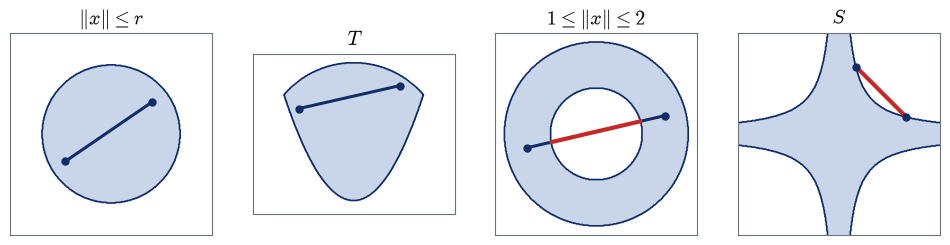

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
disk_r = 1.5
# membership, axis limits, segment ends, title
sets = [
    (lambda X, Y: X**2 + Y**2 <= disk_r**2,
     (-2.2, 2.2, -2.2, 2.2), (-1.0, -0.6), (0.9, 0.7), r"$\|x\|\leq r$"),
    (lambda X, Y: (X**2 + Y**2 <= T_radius2) & (Y >= X**2 - T_shift),
     (-2.2, 2.2, -1.3, 2.2), (-1.2, 1.0), (1.0, 1.5), r"$T$"),
    (lambda X, Y: (X**2 + Y**2 >= 1) & (X**2 + Y**2 <= 4),
     (-2.2, 2.2, -2.2, 2.2), (-1.5, -0.3), (1.5, 0.4), r"$1\leq\|x\|\leq 2$"),
    (lambda X, Y: (X * Y) ** 2 <= 1,
     (-3, 3, -3, 3), (2.0, 0.5), (0.5, 2.0), r"$S$"),
]
for ax, (member, ext, p, q, title) in zip(axes, sets):
    region(ax, member, ext)
    segment(ax, member, p, q)
    clean_axes(ax, ext)
    ax.set_title(title)
save(fig, "fig_sets")
plt.show()

### Jensen's inequality for the A1 family

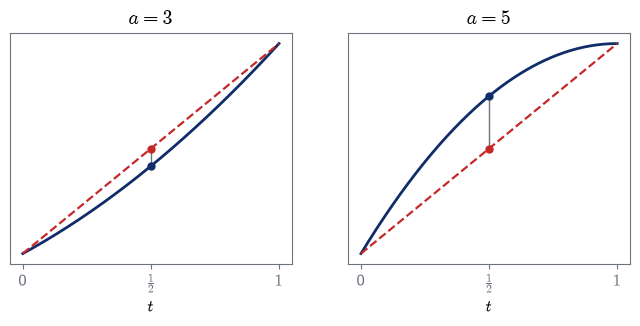

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.0))
pv, qv = np.array(A1_p, float), np.array(A1_q, float)
t = np.linspace(0, 1, 200)
for ax, a in zip(axes, (A1_aConvex, A1_aTest)):
    phi = [f_A1(pv + s * (qv - pv), a) for s in t]
    ax.plot(t, phi, color=HSE["blue"], lw=2)
    ax.plot([0, 1], [phi[0], phi[-1]], color=HSE["accent"], lw=1.6, ls="--")
    ax.plot([0.5, 0.5], [f_A1((pv + qv) / 2, a), (phi[0] + phi[-1]) / 2], color=HSE["gray"], lw=1)
    ax.plot([0.5], [f_A1((pv + qv) / 2, a)], "o", color=HSE["blue"], ms=5)
    ax.plot([0.5], [(phi[0] + phi[-1]) / 2], "o", color=HSE["accent"], ms=5)
    ax.set_xticks([0, 0.5, 1], ["$0$", r"$\frac{1}{2}$", "$1$"])
    ax.set_yticks([])
    ax.set_xlabel("$t$")
    ax.set_title(f"$a={a}$")
save(fig, "fig_jensen")
plt.show()

### Sublevel sets

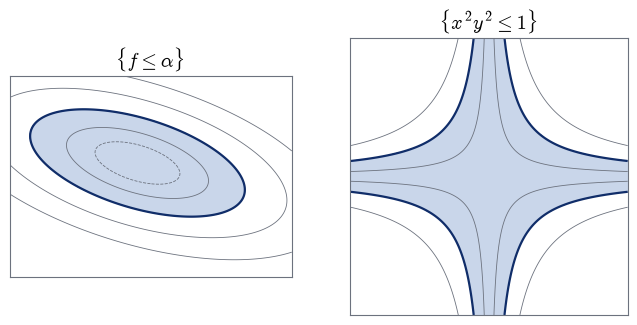

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
aS = DATA["A"]["widgets"]["sublevel"]["convexA"]
lvl_c = DATA["A"]["widgets"]["sublevel"]["levelConvex"]
lvl_n = DATA["A"]["widgets"]["sublevel"]["levelNonconvex"]

ext = (-4.5, 2.5, -2.5, 2.5)
X, Y = np.meshgrid(np.linspace(ext[0], ext[1], 320), np.linspace(ext[2], ext[3], 320))
Z = X**2 + aS * X * Y + A1_cyy * Y**2 + A1_bx * X
axes[0].contourf(X, Y, (Z <= lvl_c).astype(float), levels=[0.5, 1.5], colors=[HSE["fill"]])
axes[0].contour(X, Y, Z, levels=[-0.5, 1, 4, 9, 16], colors=[HSE["gray"]], linewidths=0.6)
axes[0].contour(X, Y, Z, levels=[lvl_c], colors=[HSE["blue"]], linewidths=1.6)
clean_axes(axes[0], ext)
axes[0].set_title(r"$\{f\leq \alpha\}$")

ext = (-3, 3, -3, 3)
X, Y = np.meshgrid(np.linspace(ext[0], ext[1], 320), np.linspace(ext[2], ext[3], 320))
Z = (X * Y) ** 2
axes[1].contourf(X, Y, (Z <= lvl_n).astype(float), levels=[0.5, 1.5], colors=[HSE["fill"]])
axes[1].contour(X, Y, Z, levels=[0.1, 4], colors=[HSE["gray"]], linewidths=0.6)
axes[1].contour(X, Y, Z, levels=[lvl_n], colors=[HSE["blue"]], linewidths=1.6)
clean_axes(axes[1], ext)
axes[1].set_title(r"$\{x^2y^2\leq 1\}$")
save(fig, "fig_sublevel")
plt.show()

### Projections onto a ball, a box and the simplex

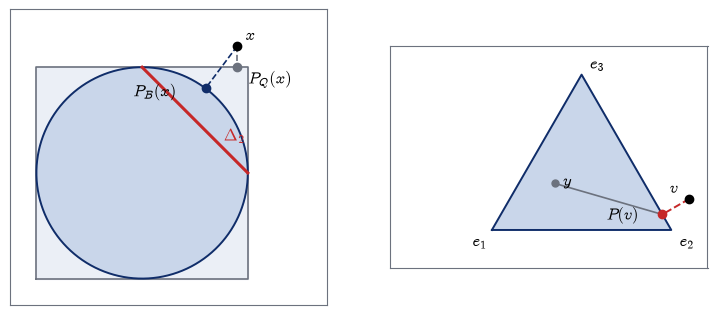

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.0))

ax = axes[0]
th = np.linspace(0, 2 * np.pi, 400)
ax.fill([-1, 1, 1, -1], [-1, -1, 1, 1], color=HSE["light"])
ax.plot([-1, 1, 1, -1, -1], [-1, -1, 1, 1, -1], color=HSE["gray"], lw=1.2)
ax.fill(np.cos(th), np.sin(th), color=HSE["fill"])
ax.plot(np.cos(th), np.sin(th), color=HSE["blue"], lw=1.4)
ax.plot([1, 0], [0, 1], color=HSE["accent"], lw=2.2)
xp = np.array(B2_x, float)
for P, color in ((np.array(B2_ball, float), HSE["blue"]), (np.array(B2_box, float), HSE["gray"])):
    ax.plot(*zip(xp, P), ls="--", color=color, lw=1.2)
    ax.plot(*P, "o", color=color, ms=6)
ax.plot(*xp, "o", color="black", ms=6)
ax.annotate("$x$", xp, textcoords="offset points", xytext=(6, 4))
ax.annotate(r"$P_B(x)$", np.array(B2_ball, float), textcoords="offset points", xytext=(-52, -6))
ax.annotate(r"$P_Q(x)$", np.array(B2_box, float), textcoords="offset points", xytext=(8, -12))
ax.annotate(r"$\Delta_2$", (0.72, 0.28), textcoords="offset points", xytext=(4, 2), color=HSE["accent"])
clean_axes(ax, (-1.25, 1.75, -1.25, 1.55))

ax = axes[1]
# the simplex in R^3 drawn as an equilateral triangle
V = np.array([[0.0, 0.0], [math.sqrt(2), 0.0], [math.sqrt(2) / 2, math.sqrt(6) / 2]])
to2d = lambda x: np.asarray(x, float) @ V
ax.fill(V[:, 0], V[:, 1], color=HSE["fill"])
ax.plot(*np.vstack([V, V[:1]]).T, color=HSE["blue"], lw=1.4)
vin = to2d(B3_inplane)
Pv = to2d(B3["x"])
yv = to2d([fr("0.5"), fr("0.2"), fr("0.3")])
ax.plot(*zip(vin, Pv), ls="--", color=HSE["accent"], lw=1.4)
ax.plot(*zip(yv, Pv), ls="-", color=HSE["gray"], lw=1.2)
ax.plot(*vin, "o", color="black", ms=6)
ax.plot(*Pv, "o", color=HSE["accent"], ms=6)
ax.plot(*yv, "o", color=HSE["gray"], ms=5)
for k, lab in enumerate(("$e_1$", "$e_2$", "$e_3$")):
    ax.annotate(lab, V[k], textcoords="offset points", xytext=(-14 if k == 0 else 6, -12 if k < 2 else 4))
ax.annotate("$v$", vin, textcoords="offset points", xytext=(-14, 4))
ax.annotate(r"$P(v)$", Pv, textcoords="offset points", xytext=(-40, -4))
ax.annotate("$y$", yv, textcoords="offset points", xytext=(6, -2))
clean_axes(ax, (-0.8, 1.7, -0.3, 1.45))
save(fig, "fig_projections")
plt.show()

### KKT geometry of C1, C2 and C3

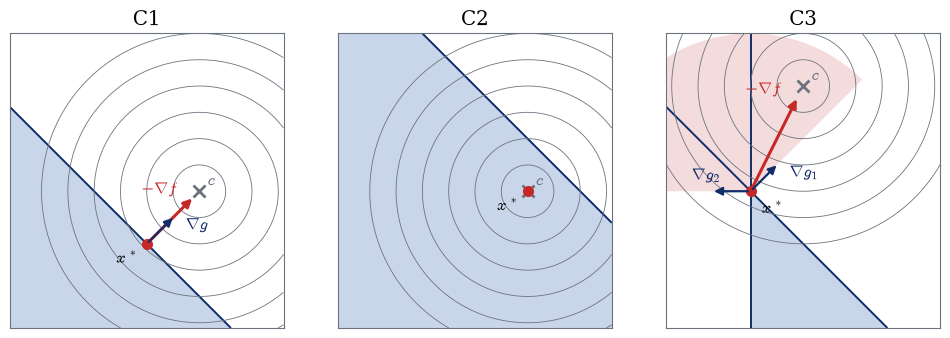

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
ext = (-1.6, 3.6, -1.6, 4.0)
X, Y = np.meshgrid(np.linspace(ext[0], ext[1], 320), np.linspace(ext[2], ext[3], 320))
for ax, (pid, best) in zip(axes, (("C1", C1), ("C2", C2), ("C3", C3))):
    P = DATA[pid]["params"]
    c = np.array(P["c"], float)
    A = np.array(P["A"], float)
    b = np.array(P["b"], float)
    feas = np.all([A[i, 0] * X + A[i, 1] * Y <= b[i] for i in range(len(b))], axis=0)
    ax.contourf(X, Y, feas.astype(float), levels=[0.5, 1.5], colors=[HSE["fill"]])
    for i in range(len(b)):
        ax.contour(X, Y, A[i, 0] * X + A[i, 1] * Y - b[i], levels=[0], colors=[HSE["blue"]], linewidths=1.4)
    ax.contour(X, Y, (X - c[0]) ** 2 + (Y - c[1]) ** 2, levels=[0.25, 1, 2.25, 4, 6.25, 9],
               colors=[HSE["gray"]], linewidths=0.6)
    xs = np.array(best["x"], float)
    lam = np.array(best["lam"], float)
    ax.plot(*c, "x", color=HSE["gray"], ms=8, mew=2)
    ax.annotate("$c$", c, textcoords="offset points", xytext=(6, 4), color=HSE["gray"])
    if np.any(lam > 0):
        # the cone spanned by the gradients of the active constraints
        dirs = [A[i] / np.linalg.norm(A[i]) for i in range(len(b)) if lam[i] > 0]
        angles = sorted(math.atan2(d[1], d[0]) for d in dirs)
        if len(angles) == 2 and angles[1] - angles[0] > np.pi:
            angles = [angles[1], angles[0] + 2 * np.pi]
        arc = np.linspace(angles[0], angles[-1], 40)
        cone = np.vstack([xs, xs + 3 * np.c_[np.cos(arc), np.sin(arc)]])
        ax.fill(cone[:, 0], cone[:, 1], color=HSE["fill2"], alpha=0.8, lw=0)
        mg = -2 * (xs - c)
        tip = xs + 0.45 * mg
        ax.annotate("", tip, xs, arrowprops=dict(arrowstyle="-|>", color=HSE["accent"], lw=2.2))
        ax.annotate(r"$-\nabla f$", tip, textcoords="offset points", xytext=(-38, 2), color=HSE["accent"])
        for i in range(len(b)):
            if lam[i] > 0:
                unit = A[i] / np.linalg.norm(A[i])
                arrow = dict(arrowstyle="-|>", color=HSE["blue"], lw=1.6)
                ax.annotate("", xs + 0.75 * unit, xs, arrowprops=arrow)
                label = r"$\nabla g$" if len(b) == 1 else rf"$\nabla g_{i + 1}$"
                offset = (8, -10) if unit[0] > 0 else (-14, 8)
                ax.annotate(label, xs + 0.75 * unit, textcoords="offset points", xytext=offset,
                            color=HSE["blue"])
    ax.plot(*xs, "o", color=HSE["accent"], ms=7)
    ax.annotate(r"$x^*$", xs, textcoords="offset points", xytext=(8, -16) if pid == "C3" else (-22, -14))
    clean_axes(ax, ext)
    ax.set_title(pid)
save(fig, "fig_kkt")
plt.show()

### Dual functions of C1 and D2, and the Boolean duality gap

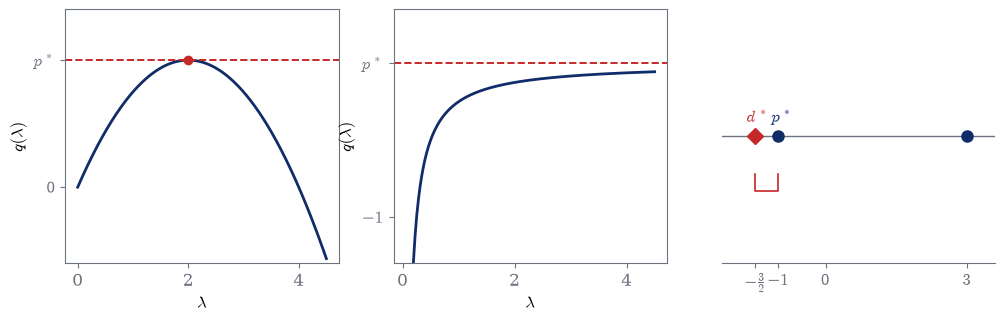

In [34]:
D3_values = sorted(set(vals))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.3))

ax = axes[0]
lam = np.linspace(0, 4.5, 300)
ax.plot(lam, 2 * lam - lam**2 / 2, color=HSE["blue"], lw=2)
ax.axhline(float(C1["f"]), color=HSE["accent"], ls="--", lw=1.4)
ax.plot([2], [2], "o", color=HSE["accent"], ms=6)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$q(\lambda)$")
ax.set_xticks([0, 2, 4])
ax.set_yticks([0, 2], ["$0$", r"$p^*$"])
ax.set_ylim(-1.2, 2.8)

ax = axes[1]
lam = np.linspace(0.06, 4.5, 300)
ax.plot(lam, -1 / (4 * lam), color=HSE["blue"], lw=2)
ax.axhline(0, color=HSE["accent"], ls="--", lw=1.4)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$q(\lambda)$")
ax.set_xticks([0, 2, 4])
ax.set_yticks([-1, 0], ["$-1$", r"$p^*$"])
ax.set_ylim(-1.3, 0.35)

ax = axes[2]
ax.axhline(0, color=HSE["gray"], lw=1)
for v in D3_values:
    ax.plot([v], [0], "o", color=HSE["blue"], ms=8)
ax.plot([float(d_bool)], [0], "D", color=HSE["accent"], ms=8)
ax.annotate(r"$p^*$", (float(p_bool), 0), textcoords="offset points", xytext=(-5, 10), color=HSE["blue"])
ax.annotate(r"$d^*$", (float(d_bool), 0), textcoords="offset points", xytext=(-6, 10), color=HSE["accent"])
ax.plot([float(d_bool), float(d_bool), float(p_bool), float(p_bool)], [-0.18, -0.26, -0.26, -0.18],
        color=HSE["accent"], lw=1.2)
ax.set_xticks([float(d_bool), float(p_bool), 0, 3], [r"$-\frac{3}{2}$", "$-1$", "$0$", "$3$"])
ax.set_yticks([])
ax.set_xlim(-2.2, 3.6)
ax.set_ylim(-0.6, 0.6)
for side in ("left", "right", "top"):
    ax.spines[side].set_visible(False)
save(fig, "fig_duality")
plt.show()

### Projected gradient on the two disks and on the capsule

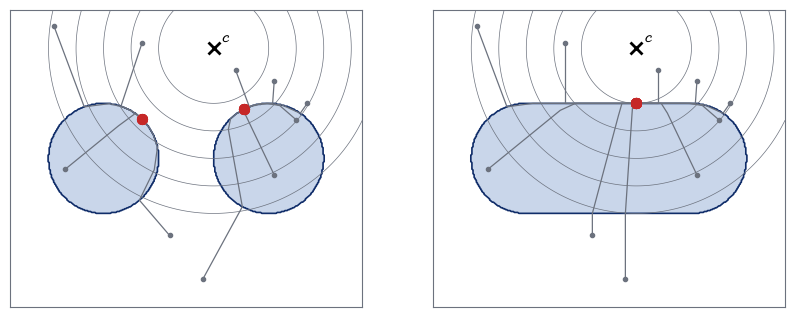

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
ext = (-3.2, 3.2, -2.7, 2.7)
X, Y = np.meshgrid(np.linspace(ext[0], ext[1], 320), np.linspace(ext[2], ext[3], 320))
union = ((X + 1.5) ** 2 + Y**2 <= 1) | ((X - 1.5) ** 2 + Y**2 <= 1)
capsule = np.minimum(np.hypot(X - np.clip(X, -1.5, 1.5), Y), 10) <= 1
for ax, member, proj in ((axes[0], union, proj_two_disks), (axes[1], capsule, proj_capsule)):
    ax.contourf(X, Y, member.astype(float), levels=[0.5, 1.5], colors=[HSE["fill"]])
    ax.contour(X, Y, member.astype(float), levels=[0.5], colors=[HSE["blue"]], linewidths=1.2)
    ax.contour(X, Y, (X - D1_c[0]) ** 2 + (Y - D1_c[1]) ** 2, levels=[1, 2.25, 4, 6.25, 9],
               colors=[HSE["gray"]], linewidths=0.5)
    for s in D1_starts:
        _, info = projected_gradient(f_D1, grad_D1, s, proj, step=D1_step)
        path = np.vstack([s, info["path"]])
        ax.plot(path[:, 0], path[:, 1], color=HSE["gray"], lw=0.9)
        ax.plot(*s, "o", color=HSE["gray"], ms=3)
        ax.plot(*info["path"][-1], "o", color=HSE["accent"], ms=7)
    ax.plot(*D1_c, "x", color="black", ms=8, mew=2)
    ax.annotate("$c$", D1_c, textcoords="offset points", xytext=(6, 4))
    clean_axes(ax, ext)
save(fig, "fig_pgd")
plt.show()

## 12. Export

In [36]:
put("figures", sorted(FIGURES))
put("meta.seed", SEED)
versions_md = VENDOR / "VERSIONS.md"
libraries = {}
if versions_md.exists():
    for line in versions_md.read_text(encoding="utf-8").splitlines():
        cells = [c.strip() for c in line.strip().strip("|").split("|")]
        if len(cells) >= 4 and re.fullmatch(r"\d+\.\d+(\.\d+)?", cells[1]):
            libraries[re.sub(r"[^A-Za-z0-9]", "", cells[0]).lower()] = cells[1]
put("meta.libraries", libraries)

CODE = {
    "convexity": [classify_eigenvalues, check_convexity],
    "projBall": [proj_ball],
    "projBox": [proj_box],
    "projSimplex": [proj_simplex],
    "kkt": [kkt_check],
    "pgd": [projected_gradient],
}
DATA["code"] = {k: "\n\n".join(inspect.getsource(fn).rstrip() for fn in fns) + "\n" for k, fns in CODE.items()}

GENERATED = f"Generated by checks/{NOTEBOOK}. Do not edit by hand."
LICENCE = ["SPDX-License-Identifier: MIT", "Copyright (c) 2026 Evgeny Baulin"]
payload = json.dumps(DATA, sort_keys=True, indent=1, ensure_ascii=True)
data_js = ("".join(f"// {line}\n" for line in [GENERATED, *LICENCE])
           + "window.SEM = window.SEM || {};\nwindow.SEM.data = /*JSON-BEGIN*/" + payload + "/*JSON-END*/;\n")
(WEB / "data").mkdir(parents=True, exist_ok=True)
(WEB / "data" / "seminar02_data.js").write_text(data_js, encoding="utf-8")


def ru_tex(s):
    s = re.sub(r"(\d)\.(\d)", r"\1{,}\2", s)
    return s.replace(r",\ ", r";\ ")


def tex_leaf(key, value, lang):
    """TeX for one exported value, or None when the value has no TeX form."""
    if isinstance(value, bool):
        return None
    if isinstance(value, (int, float)):
        return tex_num(value, lang)
    if isinstance(value, str):
        if ".tex." in key or key.endswith(".tex"):
            return ru_tex(value) if lang == "ru" else value
        return None
    if not (isinstance(value, list) and value):
        return None
    if all(isinstance(v, (int, float)) and not isinstance(v, bool) for v in value) and len(value) <= 10:
        sep = r";\ " if lang == "ru" else ", "
        return "(" + sep.join(tex_num(v, lang) for v in value) + ")"
    matrix = all(isinstance(r, list) and r and all(isinstance(v, (int, float)) for v in r) for r in value)
    if matrix and len(value) <= 4:
        return tex_mat(value) if lang == "en" else ru_tex(tex_mat(value))
    return None


def flatten(node, prefix=""):
    if isinstance(node, dict):
        for k in sorted(node):
            yield from flatten(node[k], f"{prefix}.{k}" if prefix else k)
    else:
        yield prefix, node
        if isinstance(node, list) and len(node) <= 10:
            for i, item in enumerate(node, start=1):
                yield from flatten(item, f"{prefix}.{i}")


TEX_VALUES = {}
for key, value in flatten({k: v for k, v in DATA.items() if k not in ("code", "meta")}):
    for lang in ("en", "ru"):
        tex = tex_leaf(key, value, lang)
        if tex is not None:
            assert "%" not in tex and "#" not in tex, key
            TEX_VALUES[(lang, key)] = tex

lines = [
    f"% {GENERATED}",
    *(f"% {line}" for line in LICENCE),
    "%",
    "% Usage: \\def\\valuelang{en} or \\def\\valuelang{ru} before \\input{values}, then \\val{A1.params.aTest}.",
    "% Vector and list entries are indexed from 1: \\val{B1.steps.u.1}. An undefined key stops the compilation.",
    "\\providecommand{\\valuelang}{en}",
    "\\newcommand{\\val}[1]{%",
    "  \\ifcsname s02val@\\valuelang @#1\\endcsname",
    "    \\csname s02val@\\valuelang @#1\\endcsname",
    "  \\else",
    "    \\errmessage{values.tex: undefined key #1}%",
    "  \\fi}",
]
for (lang, key), tex in sorted(TEX_VALUES.items()):
    lines.append(f"\\expandafter\\def\\csname s02val@{lang}@{key}\\endcsname{{{tex}}}")
values_tex = "\n".join(lines) + "\n"
THEORY.mkdir(parents=True, exist_ok=True)
values_path = THEORY / "values.tex"
# a rewrite with the same bytes would make values.tex look newer than the PDFs built from it
if not values_path.is_file() or values_path.read_text(encoding="utf-8") != values_tex:
    values_path.write_text(values_tex, encoding="utf-8")
print(f"data: {len(payload):,} characters; values.tex: {len(TEX_VALUES) // 2} keys per language")

data: 22,411 characters; values.tex: 778 keys per language


## 13. Consistency of the web files

The content files, pages and handouts of this seminar are read back against the export. Cyrillic is allowed only in RU strings and in `*_ru.tex` files, and the only URL is the Telegram link.

In [37]:
CYR = re.compile("[\\u0400-\\u04FF]")
LETTER = re.compile("[A-Za-z\\u0400-\\u04FF]")
TOKEN = re.compile(r"\{\{\s*([A-Za-z0-9.]+)\s*\}\}")
TELEGRAM = "https://t.me/tarakan_tuc"
PAGES = [WEB / name for name in ("main.html", "theory.html", "cheatsheet.html")]
LANDING = WEB_ROOT / "index.html"
TEXT_SUFFIXES = {".html", ".css", ".js", ".tex", ".md", ".svg", ".ipynb", ".json", ".py", ".txt"}
ALLOWED_NUMBERS = {"0", "1", "2", "02", "2026", "2027"}


def files_under(roots, suffixes):
    """Files with the given suffixes under folders or single files, without vendor/ and notebook checkpoints."""
    found = set()
    for root in roots:
        for path in [root] if root.is_file() else root.rglob("*"):
            if (path.is_file() and path.suffix in suffixes and not path.is_relative_to(VENDOR)
                    and ".ipynb_checkpoints" not in path.parts):
                found.add(path)
    return sorted(found)


JS_FILES = files_under([WEB, SHARED], {".js"})
CONTENT_FILES = [p for p in JS_FILES if p.name.startswith("content-")]
WEB_ROOT_R = WEB_ROOT.resolve()


def local_target(base, link):
    """The existing file inside web/ that a relative link points to, or None."""
    target = (base / link.split("#")[0].split("?")[0]).resolve()
    return target if target.is_relative_to(WEB_ROOT_R) and target.exists() else None


def marked_json(path):
    """The JSON between /*JSON-BEGIN*/ and /*JSON-END*/, and the rest of the file."""
    text = path.read_text(encoding="utf-8")
    m = re.search(r"/\*JSON-BEGIN\*/(.*)/\*JSON-END\*/", text, re.S)
    if m is None:
        return None, text
    return json.loads(m.group(1)), text[:m.start()] + text[m.end():]


def data_lookup(path):
    """The exported value at a dotted path, list entries indexed from 1; None if absent."""
    node = DATA
    for part in path.split("."):
        if isinstance(node, dict) and part in node:
            node = node[part]
        elif isinstance(node, list) and part.isdigit() and 1 <= int(part) <= len(node):
            node = node[int(part) - 1]
        else:
            return None
    return node


def walk_strings(node, path="", lang=None):
    if isinstance(node, dict):
        is_pair = set(node) == {"en", "ru"}
        for k, v in node.items():
            yield from walk_strings(v, f"{path}.{k}", k if is_pair else lang)
    elif isinstance(node, list):
        for i, v in enumerate(node):
            yield from walk_strings(v, f"{path}[{i}]", lang)
    elif isinstance(node, str):
        yield path, lang, node


def walk_pairs(node, path=""):
    if isinstance(node, dict):
        if set(node) == {"en", "ru"}:
            yield path, node
            return
        for k, v in node.items():
            yield from walk_pairs(v, f"{path}.{k}")
    elif isinstance(node, list):
        for i, v in enumerate(node):
            yield from walk_pairs(v, f"{path}[{i}]")


def walk_keys(node, key):
    if isinstance(node, dict):
        for k, v in node.items():
            if k == key and isinstance(v, str):
                yield v
            yield from walk_keys(v, key)
    elif isinstance(node, list):
        for v in node:
            yield from walk_keys(v, key)


def pdf_pages(path):
    """Page count from the /Type /Pages dictionaries, also inside compressed object streams."""
    raw = Path(path).read_bytes()
    blobs = [raw]
    for m in re.finditer(rb"stream\r?\n(.*?)\r?\nendstream", raw, re.S):
        try:
            blobs.append(zlib.decompressobj().decompress(m.group(1)))
        except zlib.error:
            pass
    counts = []
    for b in blobs:
        for d in re.findall(rb"<<(?:[^<>]|<<[^<>]*>>)*?/Type\s*/Pages\b(?:[^<>]|<<[^<>]*>>)*?>>", b):
            counts += [int(c) for c in re.findall(rb"/Count\s+(\d+)", d)]
    return max(counts) if counts else None


def strip_math(s):
    s = TOKEN.sub(" ", s)
    return re.sub(r"\$\$.*?\$\$|\$.*?\$", " ", s, flags=re.S)


def stray_numbers(s):
    s = TOKEN.sub(" ", s)
    s = re.sub(r"[_^]\{[^{}]*\}", " ", s)
    s = re.sub(r"[_^]\d", " ", s)
    found = re.findall("(?<![A-Za-z\\u0400-\\u04FF\\\\\\d.,])\\d+(?:[.,]\\d+)?", s)
    return [n for n in found if n not in ALLOWED_NUMBERS]

In [38]:
CONTENT = {}
for path in CONTENT_FILES:
    obj, rest = marked_json(path)
    check(f"consistency: {path.name} has strict JSON between the markers", obj is not None, True)
    if obj is None:
        continue
    CONTENT[path.name] = obj
    check(f"consistency: {path.name} has no Cyrillic outside the JSON", CYR.search(rest) is None, True)
    bad_tokens = sorted({t for _, _, s in walk_strings(obj) for t in TOKEN.findall(s)
                         if data_lookup(t) is None or isinstance(data_lookup(t), dict)})
    check(f"consistency: {path.name}: every token resolves in the data", bad_tokens, [])
    pairs = list(walk_pairs(obj))
    empty = [p for p, d in pairs if not d["en"].strip() or not d["ru"].strip()]
    check(f"consistency: {path.name}: every string has non-empty en and ru", empty, [])
    same = [p for p, d in pairs if len(LETTER.findall(strip_math(d["en"]))) >= 3 and d["en"] == d["ru"]]
    check(f"consistency: {path.name}: prose strings differ between the languages", same, [])
    cyr_outside = [p for p, lang, s in walk_strings(obj) if lang != "ru" and CYR.search(s)]
    check(f"consistency: {path.name}: Cyrillic only in RU strings", cyr_outside, [])
    numbers = sorted({f"{p}: {n}" for p, lang, s in walk_strings(obj) if lang in ("en", "ru")
                      for n in stray_numbers(s)})
    check(f"consistency: {path.name}: no hard-coded non-structural numbers", numbers, [])
    missing_assets = sorted({v for key in ("href", "src") for v in walk_keys(obj, key)
                             if not v.startswith(TELEGRAM) and local_target(WEB, v) is None})
    check(f"consistency: {path.name}: asset paths exist", missing_assets, [])
check("consistency: the content files exist",
      [p.relative_to(WEB_ROOT).as_posix() for p in CONTENT_FILES if p.name in CONTENT],
      [f"{SEMINAR}/js/content-{name}.js" for name in ("cheatsheet", "handout", "main", "problems", "ui")]
      + ["shared/js/content-common.js"])

# problems, mistakes, exit ticket and home practice
problems = CONTENT.get("content-problems.js", {}).get("problems", {})
check("consistency: nine problems", sorted(problems), ["A1", "A2", "A3", "B1", "B2", "B3", "C1", "C2", "C3"])
PROBLEM_KEYS = ("title", "skill", "statement", "steps", "answerText", "answers", "hints", "mistakes", "check")
structure = []
for pid, P in problems.items():
    ok = (P.get("who") == ("board" if pid.endswith("1") else "students")
          and all(k in P for k in PROBLEM_KEYS)
          and len(P["hints"]) == 2
          and 1 <= len(P["mistakes"]) <= 2
          and len(P["steps"]) >= 3
          and all(isinstance(data_lookup(a["ref"]), dict) and "type" in data_lookup(a["ref"])
                  for a in P["answers"]))
    if not ok:
        structure.append(pid)
check("consistency: every problem has statement, steps, answers, two hints, mistakes and a check",
      structure, [])
main = CONTENT.get("content-main.js", {}).get("main", {})
wrap = main.get("blocks", {}).get("E", {})
check("consistency: two to four common mistakes per subtopic",
      [2 <= len(main.get("mistakes", {}).get(b, [])) <= 4 for b in "ABC"], [True, True, True])
check("consistency: exit ticket has three questions, home practice four problems",
      [len(wrap.get("exit", {}).get("items", [])), len(wrap.get("home", {}).get("items", []))], [3, 4])
check("consistency: home practice has three problems by hand and one in code",
      sorted(item.get("kind") for item in wrap.get("home", {}).get("items", [])),
      ["code", "hand", "hand", "hand"])

# Cyrillic in the other files
cyr_files = []
for path in files_under([WEB, SHARED, LANDING, THEORY], TEXT_SUFFIXES) + [NB_PATH]:
    if path.name.endswith("_ru.tex") or path in CONTENT_FILES:
        continue
    if CYR.search(path.read_text(encoding="utf-8", errors="ignore")):
        cyr_files.append(path.relative_to(AUTHOR).as_posix())
check("consistency: Cyrillic appears only in RU content strings and *_ru.tex files", cyr_files, [])

# URLs, modules and network loaders
url_hits = []
for path in files_under([WEB, SHARED, LANDING], {".html", ".css", ".js"}):
    for url in re.findall(r"https?://[^\s\"'<>)\\]+", path.read_text(encoding="utf-8")):
        if url != TELEGRAM:
            url_hits.append(f"{path.relative_to(WEB_ROOT).as_posix()}: {url}")
check("consistency: no URL except the Telegram link in web/02, web/shared (without vendor) and web/index.html",
      url_hits, [])
LOADERS = [
    ("type=module", r"type\s*=\s*['\"]module['\"]"),
    ("import", "(?<![.\\w$'\"])import\\b"),
    ("fetch", r"\bfetch\s*\("),
    ("XMLHttpRequest", r"XMLHttpRequest"),
]
forbidden = []
for path in JS_FILES + PAGES + [LANDING]:
    text = path.read_text(encoding="utf-8") if path.exists() else ""
    for label, pattern in LOADERS:
        if re.search(pattern, text):
            forbidden.append(f"{path.relative_to(WEB_ROOT).as_posix()}: {label}")
check("consistency: web/02, web/shared and web/index.html have no modules, import, fetch or XMLHttpRequest",
      forbidden, [])

# relative links and assets
missing = []
for page in PAGES + [LANDING]:
    if not page.exists():
        missing.append(f"{page.relative_to(WEB_ROOT).as_posix()} (page)")
        continue
    for link in re.findall(r"(?:href|src)\s*=\s*\"([^\"]*)\"", page.read_text(encoding="utf-8")):
        if link.startswith(("#", TELEGRAM, "mailto:")) or not link:
            continue
        if link.startswith(("/", "http")) or local_target(page.parent, link) is None:
            missing.append(f"{page.relative_to(WEB_ROOT).as_posix()}: {link}")
for css in files_under([WEB, SHARED], {".css"}):
    for link in re.findall(r"url\(([^)]+)\)", css.read_text(encoding="utf-8")):
        link = link.strip("'\" ")
        if not link.startswith("data:") and local_target(css.parent, link) is None:
            missing.append(f"{css.relative_to(WEB_ROOT).as_posix()}: {link}")
check("consistency: every relative link and asset of the pages exists", missing, [])

# handouts against theory.html
VAL = re.compile(r"\\val\{([^{}]+)\}")
tex_keys_en = {key for (lang, key) in TEX_VALUES if lang == "en"}
handout = CONTENT.get("content-handout.js", {}).get("handout", {})
html_structure = []
for s in handout.get("sections", []):
    html_structure.append(f"sec:{s['id']}")
    html_structure += [f"sub:{sub['id']}" for sub in s.get("subsections", [])]
STRUCT = re.compile(r"\\(section|subsection)\*?\{.*\}\\label\{(sec|sub):([a-z0-9-]+)\}")
for lang in ("en", "ru"):
    path = THEORY / f"Theory_{lang}.tex"
    text = path.read_text(encoding="utf-8") if path.exists() else ""
    tex_structure = [f"{kind}:{ident}" for _, kind, ident in STRUCT.findall(text)]
    check(f"consistency: Theory_{lang}.tex has the section structure of theory.html", tex_structure,
          html_structure if html_structure else ["missing theory.html structure"])
    check(f"consistency: Theory_{lang}.tex: every \\val key exists",
          sorted(set(VAL.findall(text)) - tex_keys_en), [])
FIGREF = re.compile(r"\\handoutfigure\{[^{}]*\}\{([^{}]+)\}")
for lang in ("en", "ru"):
    path = THEORY / f"Theory_{lang}.tex"
    text = path.read_text(encoding="utf-8") if path.exists() else ""
    if "{figures/#2.pdf}" in text:
        figure_offenders = sorted(n for n in FIGREF.findall(text) if not (FIG_PDF / f"{n}.pdf").exists())
    else:
        figure_offenders = ["macro path"]
    check(f"consistency: Theory_{lang}.tex: figures/ next to the tex has every figure", figure_offenders, [])
for lang in ("en", "ru"):
    path = THEORY / f"Cheatsheet_{lang}.tex"
    text = path.read_text(encoding="utf-8") if path.exists() else None
    check(f"consistency: Cheatsheet_{lang}.tex exists and its \\val keys exist",
          sorted(set(VAL.findall(text)) - tex_keys_en) if text is not None else ["missing"], [])

INPUTREF = re.compile(r"\\input\{([^{}]+)\}")
GRAPHICREF = re.compile(r"\\includegraphics(?:\[[^\]]*\])?\{([^{}]+)\}")


def pdf_sources(name):
    """Everything a document is built from: its .tex, the files it inputs and the figures it includes."""
    tex = THEORY / f"{name}.tex"
    text = tex.read_text(encoding="utf-8") if tex.exists() else ""
    inputs = [THEORY / (s if s.endswith(".tex") else f"{s}.tex") for s in INPUTREF.findall(text)]
    graphics = [THEORY / t for t in GRAPHICREF.findall(text) if "#" not in t]
    figures = [FIG_PDF / f"{n}.pdf" for n in FIGREF.findall(text)]
    return list(dict.fromkeys([tex] + inputs + graphics + figures))


pdf_problems = []
for name in ("Theory_en", "Theory_ru", "Cheatsheet_en", "Cheatsheet_ru"):
    pdf, log = THEORY / f"{name}.pdf", THEORY / f"{name}.log"
    if not pdf.exists():
        pdf_problems.append(f"{name}.pdf missing")
        continue
    for source in pdf_sources(name):
        rel = source.relative_to(THEORY).as_posix()
        if not source.exists():
            pdf_problems.append(f"{name}.pdf: {rel} missing")
        elif pdf.stat().st_mtime < source.stat().st_mtime - 2:
            pdf_problems.append(f"{name}.pdf older than {rel}")
    if name.startswith("Cheatsheet") and pdf_pages(pdf) != 1:
        pdf_problems.append(f"{name}.pdf has {pdf_pages(pdf)} pages")
    if log.exists() and "Overfull \\hbox" in log.read_text(encoding="utf-8", errors="ignore"):
        pdf_problems.append(f"{name}.log: Overfull \\hbox")
check("consistency: every PDF is newer than its sources, the cheat sheets have one page and no log "
      "reports an overfull box", pdf_problems, [])

# the exported files on disk
disk_data, _ = marked_json(WEB / "data" / "seminar02_data.js")
check("consistency: the data file parses back to the exported data", disk_data == json.loads(payload), True)
check("consistency: values.tex on disk is the export",
      (THEORY / "values.tex").read_text(encoding="utf-8") == values_tex, True)
check("consistency: every figure exists as .svg (web) and .pdf (theory)",
      [n for n in FIGURES if not ((FIG_SVG / f"{n}.svg").exists() and (FIG_PDF / f"{n}.pdf").exists())], [])
check("consistency: vendored library versions are recorded", sorted(libraries), ["katex", "mathjs", "ptserif"])
rows = section("consistency")
print(f"{int(rows['passed'].sum())} of {len(rows)} consistency checks passed")
if not rows["passed"].all():
    display(rows[~rows["passed"]])

71 of 71 consistency checks passed


## 14. Summary

In [39]:
failed = [c for c in CHECKS if not c["passed"]]
print(f"{len(CHECKS) - len(failed)} of {len(CHECKS)} checks passed")
if failed:
    display(pd.DataFrame(failed, columns=["check", "computed", "expected", "passed"]))
assert not failed

283 of 283 checks passed
